# 3D BUC-Net: Bottleneck U-Net Cascade for Brain Metastases Segmentation

**Paper**: *Automatic segmentation of brain metastases in MRI using 3D BUC-Net* (Scientific Reports, 2025)

## Architecture Overview
- **Stage 1**: 3D Bottle U-Net → coarse segmentation
- **Stage 2**: 3D Bottle U-Net(raw + coarse) → refined segmentation
- **Bottleneck**: 1×1×1 reduce → 3×3×3 spatial → 1×1×1 restore
- **Norm**: Instance Norm | **Act**: LeakyReLU(0.01)
- **Stage 1 loss**: 0.4·Dice + 0.6·CE | **Stage 2 loss**: Dice + Focal(γ=2)
- **Optimizer**: RMSprop (LR=0.001) | **Epochs**: 150 | **Patch**: 128×128×128
- **Input**: 4-ch MRI (FLAIR, T1, T1ce, T2) | **Classes**: 4 (bg, necrosis, edema, enhancing)


## Cell 0 — Imports & GPU Configuration

In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, ModelCheckpoint, EarlyStopping, CSVLogger
)

print(f'TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available     : {len(gpus)}')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

SEED = 61
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Seeds set. Ready.')


TensorFlow version : 2.20.0
GPUs available     : 0
Seeds set. Ready.


## Cell 1 — Configuration Constants

In [2]:
# ── Environment flag ─────────────────────────────────────────────────────────
# Set to True when running on a machine with limited RAM (e.g. 8 GB MacBook).
# Set to False (or use the paper values below) on a GPU workstation / cluster.
LOW_MEMORY_MODE = True

# Paths
DATA_DIR = 'Dataset/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
SAVE_DIR = 'saved_models/buc_net'
os.makedirs(SAVE_DIR, exist_ok=True)

# Dataset
# BraTS2020: 0=background, 1=necrotic core, 2=peritumoral edema, 4=GD-enhancing
LABEL_MAP   = {0: 0, 1: 1, 2: 2, 4: 3}
CLASS_NAMES = ['Background', 'Necrosis', 'Edema', 'Enhancing']
NUM_CLASSES = 4
MODALITIES  = ['flair', 't1', 't1ce', 't2']
CHANNELS    = len(MODALITIES)  # 4

# ── Patch configuration ───────────────────────────────────────────────────────
# Paper (full training, GPU workstation):
#   PATCH_SIZE = (128, 128, 128)  # ~1 GB/sample at float32
#   STRIDE     = (64, 64, 64)     # 50% overlap
# 8 GB Mac (dev/test): 64³ is 8× smaller — fits comfortably in RAM
if LOW_MEMORY_MODE:
    PATCH_SIZE = (64, 64, 64)
    STRIDE     = (32, 32, 32)   # 50% overlap
else:
    PATCH_SIZE = (128, 128, 128)
    STRIDE     = (64, 64, 64)

# ── Training hyperparameters ──────────────────────────────────────────────────
# Paper: BATCH_SIZE=2, EPOCHS=120
# 8 GB Mac: batch=1 halves activation memory; keep EPOCHS low for smoke-tests
if LOW_MEMORY_MODE:
    BATCH_SIZE = 1
    EPOCHS     = 6              # smoke-test; restore to 120 for real training
else:
    BATCH_SIZE = 2
    EPOCHS     = 120
LEARNING_RATE = 0.001
TRAIN_SPLIT   = 0.8

# ── Architecture ─────────────────────────────────────────────────────────────
# Paper:   ENCODER_CHANNELS = [16, 32, 64, 128, 256]  (~30 M params)
# 8 GB Mac: halved channels → ~4× fewer params, ~2-3× less peak RAM
if LOW_MEMORY_MODE:
    ENCODER_CHANNELS = [8, 16, 32, 64, 128]
else:
    ENCODER_CHANNELS = [16, 32, 64, 128, 256]
DROPOUT_RATE = 0.5

# ── Loss weights (from paper, unchanged) ─────────────────────────────────────
STAGE1_ALPHA  = 0.4    # Dice weight in Stage 1
STAGE1_BETA   = 0.6    # CE weight in Stage 1
FOCAL_GAMMA   = 2.0    # Focal gamma (paper: gamma=2)

# Class weights for Focal loss (inversely proportional to class frequency)
# BraTS approx: bg~97%, edema~1.5%, necrosis~0.8%, enhancing~0.7%
CLASS_WEIGHTS = [0.1, 3.5, 2.0, 3.5]  # [bg, necrosis, edema, enhancing]

# ── Load patient list ─────────────────────────────────────────────────────────
patient_folders = sorted(glob.glob(os.path.join(DATA_DIR, 'BraTS20_Training_*')))
print(f'Total BraTS2020 patients: {len(patient_folders)}')

n_train       = int(TRAIN_SPLIT * len(patient_folders))
train_folders = patient_folders[:n_train]
val_folders   = patient_folders[n_train:]
print(f'Train: {len(train_folders)} | Val: {len(val_folders)}')

print(f'\n[Config] LOW_MEMORY_MODE={LOW_MEMORY_MODE}')
print(f'  PATCH_SIZE={PATCH_SIZE}  BATCH_SIZE={BATCH_SIZE}')
print(f'  ENCODER_CHANNELS={ENCODER_CHANNELS}  EPOCHS={EPOCHS}')


Total BraTS2020 patients: 369
Train: 295 | Val: 74

[Config] LOW_MEMORY_MODE=True
  PATCH_SIZE=(64, 64, 64)  BATCH_SIZE=1
  ENCODER_CHANNELS=[8, 16, 32, 64, 128]  EPOCHS=6


## Cell 2 — Dataset Visualization

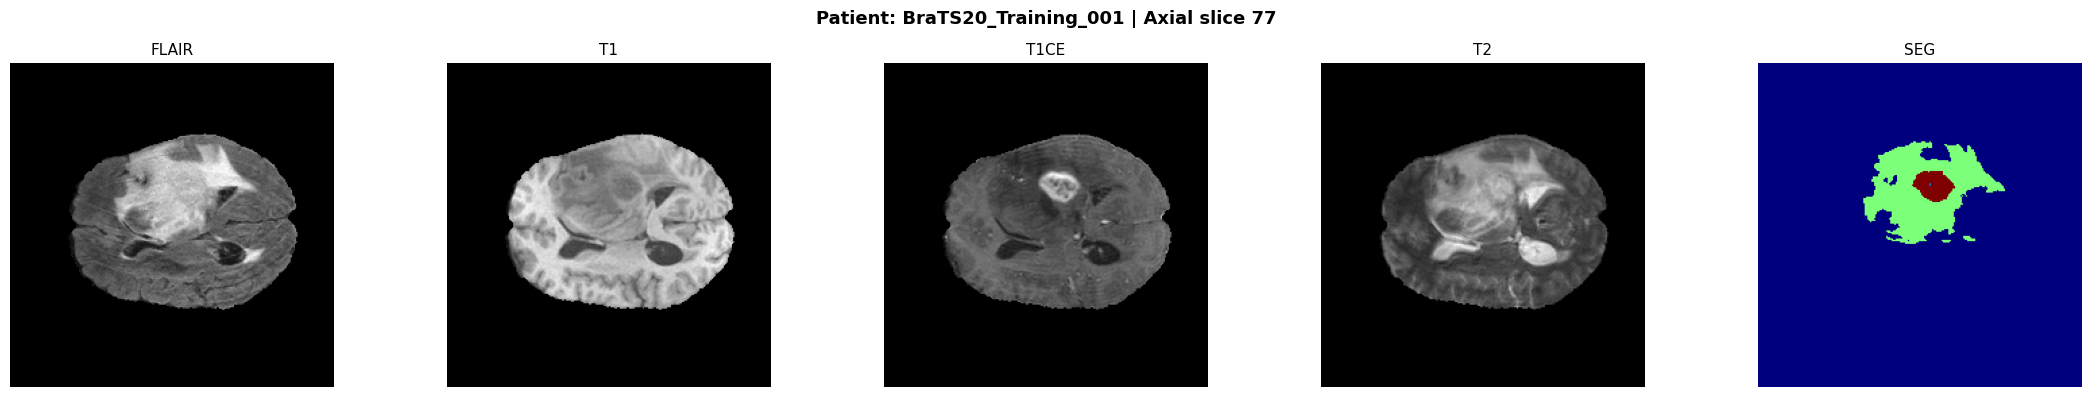

Volume shape: (240, 240, 155) | Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Label distribution for BraTS20_Training_001:
  Label 0 (  Background): 8,716,021 voxels (97.626%)
  Label 1 (    Necrosis):    15,443 voxels (0.173%)
  Label 2 (       Edema):   168,794 voxels (1.891%)
  Label 4 (   Enhancing):    27,742 voxels (0.311%)


In [3]:
def visualize_patient(patient_path, slice_idx=None):
    pid   = os.path.basename(patient_path)
    paths = {m: os.path.join(patient_path, f'{pid}_{m}.nii') for m in MODALITIES + ['seg']}
    flair = nib.load(paths['flair']).get_fdata()
    if slice_idx is None:
        slice_idx = flair.shape[2] // 2
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f'Patient: {pid} | Axial slice {slice_idx}', fontsize=13, fontweight='bold')
    cmaps = ['gray', 'gray', 'gray', 'gray', 'jet']
    for i, (key, cmap) in enumerate(zip(MODALITIES + ['seg'], cmaps)):
        img = nib.load(paths[key]).get_fdata()
        axes[i].imshow(img[:, :, slice_idx], cmap=cmap)
        axes[i].set_title(key.upper(), fontsize=11)
        axes[i].axis('off')
    plt.tight_layout(); plt.show()
    print(f'Volume shape: {flair.shape} | Spacing: {nib.load(paths["flair"]).header.get_zooms()[:3]}')


def visualize_label_distribution(patient_path):
    pid     = os.path.basename(patient_path)
    seg_raw = nib.load(os.path.join(patient_path, f'{pid}_seg.nii')).get_fdata().astype(int)
    label_names = {0: 'Background', 1: 'Necrosis', 2: 'Edema', 4: 'Enhancing'}
    print(f'Label distribution for {pid}:')
    for u, c in zip(*np.unique(seg_raw, return_counts=True)):
        name = label_names.get(u, '?')
        print(f'  Label {u} ({name:>12}): {c:>9,} voxels ({100*c/seg_raw.size:.3f}%)')


if patient_folders:
    visualize_patient(patient_folders[0])
    visualize_label_distribution(patient_folders[0])


## Cell 3 — Preprocessing (Normalization, Remapping, Augmentation)

In [4]:
def remap_labels(seg_raw):
    """Remap BraTS2020 labels {0,1,2,4} to {0,1,2,3}."""
    out = np.zeros_like(seg_raw, dtype=np.int32)
    for src, dst in LABEL_MAP.items():
        out[seg_raw == src] = dst
    return out


def to_onehot(seg_remapped, num_classes=NUM_CLASSES):
    """Convert integer label map (H,W,D) to one-hot (H,W,D,C)."""
    return np.eye(num_classes, dtype=np.float32)[seg_remapped.astype(np.int32)]


def normalize_volume(volume):
    """
    Z-score normalization per MRI channel, computed on non-zero voxels.
    Paper: 'all images were normalized using simple Z-score normalization'
    Args:
        volume: (H, W, D, C) float32
    """
    normalized = np.zeros_like(volume, dtype=np.float32)
    for c in range(volume.shape[-1]):
        ch   = volume[..., c]
        mask = ch > 0
        if mask.sum() > 0:
            mean = float(ch[mask].mean())
            std  = float(ch[mask].std())
            normalized[..., c] = np.where(mask, (ch - mean) / (std + 1e-8), 0.0)
    return normalized


def crop_to_nonzero(volume, seg=None):
    """Crop volume to bounding box of non-zero content across all channels."""
    mask   = np.any(volume > 0, axis=-1)
    if not np.any(mask):
        return (volume, seg) if seg is not None else volume
    coords = np.where(mask)
    mins   = [ax.min() for ax in coords]
    maxs   = [ax.max() + 1 for ax in coords]
    slices = tuple(slice(mn, mx) for mn, mx in zip(mins, maxs))
    v_crop = volume[slices + (slice(None),)]
    if seg is not None:
        return v_crop, seg[slices]
    return v_crop


# --- Augmentation (paper: random flip, zoom, elastic deformation, gamma, mirroring) ---

def random_flip(volume, seg):
    """Random flip along each of the 3 spatial axes."""
    for axis in range(3):
        if random.random() > 0.5:
            volume = np.flip(volume, axis=axis).copy()
            seg    = np.flip(seg,    axis=axis).copy()
    return volume, seg


def random_gamma(volume, gamma_range=(0.7, 1.5)):
    """Per-channel gamma intensity adjustment."""
    result = volume.copy()
    for c in range(volume.shape[-1]):
        ch = volume[..., c]
        mn, mx = float(ch.min()), float(ch.max())
        if mx > mn:
            gamma = random.uniform(*gamma_range)
            ch_n  = (ch - mn) / (mx - mn + 1e-8)
            result[..., c] = np.power(np.clip(ch_n, 0, 1), gamma) * (mx - mn) + mn
    return result


def random_mirror(volume, seg, p=0.5):
    """Random mirroring on axis 0 (left-right)."""
    if random.random() < p:
        volume = volume[::-1, :, :, :].copy()
        seg    = seg[::-1, :, :].copy()
    return volume, seg


def augment(volume, seg):
    """Full augmentation pipeline."""
    volume, seg = random_flip(volume, seg)
    volume, seg = random_mirror(volume, seg)
    volume      = random_gamma(volume)
    return volume, seg


print('Preprocessing utilities defined.')


Preprocessing utilities defined.


## Cell 4 — BUCNetGenerator (Multi-Class Patch Generator)

In [5]:
class BUCNetLoader:
    """
    Data loader for BUC-Net.
    Use .to_dataset() which wraps data loading in tf.data.Dataset.from_generator()
    for full Keras 3 compatibility (Keras 3 cannot infer output_signature from
    a Sequence that returns nested tuples for multi-output models).

    Pipeline:
        1. _filter()       -> validate patient folders
        2. _load_patient() -> load 4 MRI modalities + seg, normalize
        3. _sample_patch() -> tumor-biased 3D patch extraction
        4. augment()       -> random flip / mirror / gamma (train only)
        5. to_onehot()     -> one-hot encode segmentation
        6. to_dataset()    -> wrap in tf.data with explicit TensorSpec
    """

    REQUIRED = MODALITIES + ['seg']

    def __init__(self, patient_folders, patch_size=PATCH_SIZE,
                 do_augment=True, num_classes=NUM_CLASSES):
        self.patch_size  = patch_size
        self.do_augment  = do_augment
        self.num_classes = num_classes
        self.valid_folders, self.skipped = self._filter(list(patient_folders))
        if not self.valid_folders:
            raise ValueError('No valid patient folders found. Check DATA_DIR.')
        if self.skipped:
            print(f'  Skipped {len(self.skipped)} patients (missing files).')

    # ── Internal helpers ─────────────────────────────────────────────────────

    def _paths(self, patient_path):
        pid = os.path.basename(patient_path)
        return {k: os.path.join(patient_path, f'{pid}_{k}.nii') for k in self.REQUIRED}

    def _filter(self, folders):
        valid, skipped = [], []
        for fp in folders:
            missing = [k for k, p in self._paths(fp).items() if not os.path.exists(p)]
            (skipped if missing else valid).append(fp)
        return valid, skipped

    def _load_patient(self, patient_path):
        paths  = self._paths(patient_path)
        mods   = [nib.load(paths[m]).get_fdata().astype(np.float32) for m in MODALITIES]
        volume = normalize_volume(np.stack(mods, axis=-1))  # (H,W,D,4)
        seg    = remap_labels(nib.load(paths['seg']).get_fdata().astype(np.int32))
        return volume, seg

    def _sample_patch(self, volume, seg):
        H, W, D, _ = volume.shape
        pH, pW, pD = self.patch_size
        tumor_vox  = np.column_stack(np.where(seg > 0)) if np.any(seg > 0) else np.empty((0, 3), dtype=int)

        # 50% chance to centre patch on a tumor voxel
        if len(tumor_vox) > 0 and random.random() < 0.5:
            ctr = tumor_vox[np.random.randint(len(tumor_vox))]
            h_s = int(np.clip(ctr[0] - pH // 2, 0, max(H - pH, 0)))
            w_s = int(np.clip(ctr[1] - pW // 2, 0, max(W - pW, 0)))
            d_s = int(np.clip(ctr[2] - pD // 2, 0, max(D - pD, 0)))
        else:
            h_s = np.random.randint(0, max(H - pH + 1, 1))
            w_s = np.random.randint(0, max(W - pW + 1, 1))
            d_s = np.random.randint(0, max(D - pD + 1, 1))

        pv = volume[h_s:h_s+pH, w_s:w_s+pW, d_s:d_s+pD]
        ps = seg   [h_s:h_s+pH, w_s:w_s+pW, d_s:d_s+pD]

        # Pad if volume edge clips the patch
        pad_v = [(0, max(pH-pv.shape[0], 0)), (0, max(pW-pv.shape[1], 0)),
                 (0, max(pD-pv.shape[2], 0)), (0, 0)]
        pv = np.pad(pv, pad_v, mode='constant')
        ps = np.pad(ps, pad_v[:3], mode='constant')
        return pv[:pH, :pW, :pD], ps[:pH, :pW, :pD]

    # ── Public API ───────────────────────────────────────────────────────────

    def to_dataset(self, batch_size=BATCH_SIZE):
        """
        Build a Keras-3-compatible tf.data.Dataset.

        Uses tf.data.Dataset.from_generator() with an explicit output_signature
        so Keras 3 can correctly infer TensorSpecs for both model outputs.

        Returns:
            dataset:         Batched, prefetched tf.data.Dataset
            steps_per_epoch: Number of batches per epoch
        """
        pH, pW, pD = self.patch_size
        n  = self.num_classes

        # Explicit output signature — required by Keras 3 for multi-output models
        output_sig = (
            tf.TensorSpec(shape=(pH, pW, pD, CHANNELS), dtype=tf.float32),   # X
            (
                tf.TensorSpec(shape=(pH, pW, pD, n), dtype=tf.float32),       # Y_stage1
                tf.TensorSpec(shape=(pH, pW, pD, n), dtype=tf.float32),       # Y_stage2
            )
        )

        # Keep a local reference for the closure
        loader     = self
        do_augment = self.do_augment
        num_cls    = self.num_classes

        def _generator():
            """Infinite generator — shuffles patient list each pass."""
            folders = list(loader.valid_folders)
            while True:
                random.shuffle(folders)
                for ppath in folders:
                    try:
                        volume, seg = loader._load_patient(ppath)
                        pv, ps      = loader._sample_patch(volume, seg)
                        if do_augment:
                            pv, ps  = augment(pv, ps)
                        ps_oh = to_onehot(ps, num_cls).astype(np.float32)
                        # Both stages share the same ground-truth target
                        yield pv.astype(np.float32), (ps_oh, ps_oh)
                    except Exception:
                        continue

        ds  = tf.data.Dataset.from_generator(_generator, output_signature=output_sig)
        ds  = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        spe = max(1, len(self.valid_folders) // batch_size)

        print(f'  Dataset: {len(self.valid_folders)} patients | '
              f'steps/epoch={spe} | batch={batch_size} | aug={do_augment}')
        return ds, spe


# ── Sanity check ─────────────────────────────────────────────────────────────
if train_folders:
    _loader = BUCNetLoader(train_folders[:5], do_augment=False)
    _ds, _spe = _loader.to_dataset(batch_size=1)
    _x, (_y1, _y2) = next(iter(_ds))
    print(f'Sanity check -> X:{_x.shape} Y_s1:{_y1.shape} Y_s2:{_y2.shape}')
    print(f'X range:[{_x.numpy().min():.3f}, {_x.numpy().max():.3f}]')
    del _loader, _ds


  Dataset: 5 patients | steps/epoch=5 | batch=1 | aug=False
Sanity check -> X:(1, 64, 64, 64, 4) Y_s1:(1, 64, 64, 64, 4) Y_s2:(1, 64, 64, 64, 4)
X range:[-3.691, 10.086]


## Cell 5 — Instance Normalization + Bottleneck Block

In [6]:
class InstanceNormalization(layers.Layer):
    """
    Instance Normalization (Ulyanov et al., 2016).
    Normalizes across spatial dims (H,W,D) per sample and channel.
    Paper: 'we replaced...batch normalization...with...instance normalization'
    Better than BN for small batches (batch_size=2).
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        n = input_shape[-1]
        self.gamma = self.add_weight(shape=(n,), name='gamma', initializer='ones',  trainable=True)
        self.beta  = self.add_weight(shape=(n,), name='beta',  initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x, training=None):
        axes = list(range(1, len(x.shape) - 1))  # spatial dims only
        mean, var = tf.nn.moments(x, axes=axes, keepdims=True)
        return self.gamma * (x - mean) / tf.sqrt(var + self.epsilon) + self.beta

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'epsilon': self.epsilon})
        return cfg


def bottleneck_block(x, filters, dropout_rate=DROPOUT_RATE):
    """
    Bottleneck module (Fig. 4 in paper):
      Conv3D(1x1x1, C//4) -> IN -> LeakyReLU   [channel reduction]
      Conv3D(3x3x3, C//4) -> IN -> LeakyReLU   [spatial feature extraction]
      Conv3D(1x1x1, C   ) -> IN -> LeakyReLU   [channel restoration]
      SpatialDropout3D(0.5)
    Reduces params vs double-conv while preserving performance.
    """
    reduced = max(filters // 4, 4)

    # 1x1x1 channel reduction
    x = layers.Conv3D(reduced, (1, 1, 1), padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.01)(x)

    # 3x3x3 spatial convolution
    x = layers.Conv3D(reduced, (3, 3, 3), padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.01)(x)

    # 1x1x1 channel restoration
    x = layers.Conv3D(filters, (1, 1, 1), padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.01)(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout3D(dropout_rate)(x)
    return x


# Verify
_in  = layers.Input((16, 16, 16, 4))
_out = bottleneck_block(_in, 32)
_m   = models.Model(_in, _out)
print(f'Bottleneck block: in={_in.shape} out={_out.shape} params={_m.count_params():,}')
del _in, _out, _m


Bottleneck block: in=(None, 16, 16, 16, 4) out=(None, 16, 16, 16, 32) params=2,112


## Cell 6 — 3D Bottle U-Net Builder

In [7]:
def build_bottle_unet(input_shape, num_classes=NUM_CLASSES,
                       encoder_channels=None, dropout_rate=DROPOUT_RATE,
                       stage_name='stage1'):
    """
    3D Bottle U-Net (Fig. 4 in paper).

    Encoder (5 levels): BottleneckBlock -> MaxPool3D(2x2x2)
      channels: [16, 32, 64, 128, 256]
    Bridge:    BottleneckBlock(256)
    Decoder (5 levels): ConvTranspose3D(2x2x2) -> Concat(skip) -> BottleneckBlock
      channels: [128, 64, 32, 16]
    Output: Conv3D(1x1x1, num_classes, softmax)
    """
    if encoder_channels is None:
        encoder_channels = ENCODER_CHANNELS

    inp   = layers.Input(input_shape, name=f'{stage_name}_input')
    skips = []
    x     = inp

    # Encoder
    for lvl, ch in enumerate(encoder_channels[:-1]):
        x = bottleneck_block(x, ch, dropout_rate)
        skips.append(x)
        x = layers.MaxPooling3D((2,2,2), name=f'{stage_name}_enc_pool{lvl+1}')(x)

    # Bridge
    x = bottleneck_block(x, encoder_channels[-1], dropout_rate)

    # Decoder
    for lvl, ch in enumerate(reversed(encoder_channels[:-1])):
        x = layers.Conv3DTranspose(
            ch, (2,2,2), strides=(2,2,2), padding='same',
            name=f'{stage_name}_dec_up{lvl+1}'
        )(x)
        x = layers.Concatenate(name=f'{stage_name}_skip{lvl+1}')([x, skips[-(lvl+1)]])
        x = bottleneck_block(x, ch, dropout_rate)

    # Output
    out = layers.Conv3D(
        num_classes, (1,1,1), activation='softmax',
        name=f'{stage_name}_output'
    )(x)

    return models.Model(inp, out, name=f'{stage_name}_bottle_unet')


# Quick shape verification
_shape = (PATCH_SIZE[0], PATCH_SIZE[1], PATCH_SIZE[2], CHANNELS)
_m     = build_bottle_unet(_shape, stage_name='s1_test')
print(f'3D Bottle U-Net: input={_shape} output={_m.output_shape} params={_m.count_params():,}')
del _m


3D Bottle U-Net: input=(64, 64, 64, 4) output=(None, 64, 64, 64, 4) params=147,308


## Cell 7 — BUC-Net: Two-Stage Cascade

In [8]:
def build_buc_net(input_shape=None, num_classes=NUM_CLASSES,
                   encoder_channels=None, dropout_rate=DROPOUT_RATE):
    """
    BUC-Net: Two-stage cascade (Fig. 3 in paper).

    raw_MRI (B,D,H,W,4)
        |
        v
    Stage 1: 3D Bottle U-Net  ->  coarse_seg (B,D,H,W,4)  [Loss: DiceCE]
        |
        +-- concat(raw_MRI, coarse_seg) --> (B,D,H,W,8)
        v
    Stage 2: 3D Bottle U-Net  ->  refined_seg (B,D,H,W,4) [Loss: DiceFocal]

    Returns Keras model with 2 outputs: [coarse_seg, refined_seg]
    Total loss = L1 + L2 (end-to-end, equal weights)
    """
    if input_shape is None:
        input_shape = (PATCH_SIZE[0], PATCH_SIZE[1], PATCH_SIZE[2], CHANNELS)
    if encoder_channels is None:
        encoder_channels = ENCODER_CHANNELS

    raw_in = layers.Input(input_shape, name='raw_mri_input')

    # Stage 1
    s1_net    = build_bottle_unet(input_shape, num_classes, encoder_channels,
                                  dropout_rate, stage_name='stage1')
    coarse    = s1_net(raw_in)                     # (B,D,H,W,4)

    # Stage 2
    s2_ch     = input_shape[-1] + num_classes      # 4+4=8
    s2_shape  = input_shape[:3] + (s2_ch,)
    s2_net    = build_bottle_unet(s2_shape, num_classes, encoder_channels,
                                  dropout_rate, stage_name='stage2')
    combined  = layers.Concatenate(name='cascade_concat')([raw_in, coarse])
    refined   = s2_net(combined)                   # (B,D,H,W,4)

    buc_net   = models.Model(inputs=raw_in, outputs=[coarse, refined], name='BUC_Net_3D')

    print('=' * 55)
    print(' BUC-Net 3D built successfully')
    print('=' * 55)
    print(f'  Input shape    : {input_shape}')
    print(f'  Stage 1 params : {s1_net.count_params():,}')
    print(f'  Stage 2 params : {s2_net.count_params():,}')
    print(f'  Total params   : {buc_net.count_params():,}')
    print('=' * 55)
    return buc_net


BUC_INPUT_SHAPE = (PATCH_SIZE[0], PATCH_SIZE[1], PATCH_SIZE[2], CHANNELS)
buc_net = build_buc_net(
    input_shape      = BUC_INPUT_SHAPE,
    num_classes      = NUM_CLASSES,
    encoder_channels = ENCODER_CHANNELS,
    dropout_rate     = DROPOUT_RATE
)

# Forward-pass test
_d = tf.zeros([1] + list(BUC_INPUT_SHAPE))
_c, _r = buc_net(_d, training=False)
print(f'Forward pass OK -> coarse:{_c.shape}  refined:{_r.shape}')
del _d, _c, _r


 BUC-Net 3D built successfully
  Input shape    : (64, 64, 64, 4)
  Stage 1 params : 147,308
  Stage 2 params : 147,324
  Total params   : 294,632
Forward pass OK -> coarse:(1, 64, 64, 64, 4)  refined:(1, 64, 64, 64, 4)


## Cell 8 — Custom Loss Functions (DiceCE + DiceFocal)

In [9]:
class MultiClassDiceLoss(tf.keras.losses.Loss):
    """Soft multi-class Dice: 1 - mean_per_class(2*intersection/(sum+sum))"""
    def __init__(self, smooth=1e-6, name='dice_loss', **kw):
        super().__init__(name=name, **kw)
        self.smooth = smooth

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        axes   = [1, 2, 3]                                    # spatial dims
        inter  = tf.reduce_sum(y_true * y_pred, axis=axes)    # (B,C)
        sumGP  = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
        dice   = (2.0 * inter + self.smooth) / (sumGP + self.smooth)
        return 1.0 - tf.reduce_mean(dice)


class DiceCELoss(tf.keras.losses.Loss):
    """
    Stage 1 Loss: L1 = alpha*Dice + beta*CE   (paper: alpha=0.4, beta=0.6)
    'combined Dice loss with Cross-entropy to improve detection of small targets'
    """
    def __init__(self, alpha=STAGE1_ALPHA, beta=STAGE1_BETA,
                 smooth=1e-6, name='dice_ce', **kw):
        super().__init__(name=name, **kw)
        self.alpha = alpha
        self.beta  = beta
        self._dice = MultiClassDiceLoss(smooth=smooth)

    def call(self, y_true, y_pred):
        dice = self._dice(y_true, y_pred)
        ce   = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true, y_pred))
        return self.alpha * dice + self.beta * ce


class MultiClassFocalLoss(tf.keras.losses.Loss):
    """
    Multi-class Focal: L = -mu_k*(1-P_k)^gamma*log(P_k)
    mu_k inversely proportional to class frequency. gamma=2 (from paper).
    '(1-P_k)^gamma is the modulating factor which weighs less on easy samples'
    """
    def __init__(self, gamma=FOCAL_GAMMA, class_weights=None,
                 name='focal_loss', **kw):
        super().__init__(name=name, **kw)
        self.gamma         = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        mod    = tf.pow(1.0 - y_pred, self.gamma)
        focal  = -y_true * mod * tf.math.log(y_pred)
        if self.class_weights is not None:
            w     = tf.constant(self.class_weights, dtype=tf.float32)
            focal = focal * w
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))


class DiceFocalLoss(tf.keras.losses.Loss):
    """
    Stage 2 Loss: L2 = Dice + Focal   (paper: equal weight 1:1)
    """
    def __init__(self, gamma=FOCAL_GAMMA, class_weights=None,
                 smooth=1e-6, name='dice_focal', **kw):
        super().__init__(name=name, **kw)
        self._dice  = MultiClassDiceLoss(smooth=smooth)
        self._focal = MultiClassFocalLoss(gamma=gamma, class_weights=class_weights)

    def call(self, y_true, y_pred):
        return self._dice(y_true, y_pred) + self._focal(y_true, y_pred)


stage1_loss = DiceCELoss(alpha=STAGE1_ALPHA, beta=STAGE1_BETA)
stage2_loss = DiceFocalLoss(gamma=FOCAL_GAMMA, class_weights=CLASS_WEIGHTS)

# Sanity check
_yt = tf.one_hot(tf.zeros([1,4,4,4], tf.int32), NUM_CLASSES)
_yp = tf.nn.softmax(tf.random.uniform([1,4,4,4,NUM_CLASSES]))
print(f'Stage1 loss (random): {stage1_loss(_yt, _yp).numpy():.4f}')
print(f'Stage2 loss (random): {stage2_loss(_yt, _yp).numpy():.4f}')
print(f'Losses: Stage1=>{STAGE1_ALPHA}xDice+{STAGE1_BETA}xCE | Stage2=>Dice+Focal(g={FOCAL_GAMMA})')
del _yt, _yp


Stage1 loss (random): 1.1916
Stage2 loss (random): 0.9769
Losses: Stage1=>0.4xDice+0.6xCE | Stage2=>Dice+Focal(g=2.0)


## Cell 9 — Compile & Train

Compiled: RMSprop(LR=0.001) | Stage1=DiceCE | Stage2=DiceFocal
  Skipped 1 patients (missing files).
  Dataset: 295 patients | steps/epoch=295 | batch=1 | aug=True
  Dataset: 73 patients | steps/epoch=73 | batch=1 | aug=False
Training for up to 6 epochs...
Epoch 1/6
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - loss: 2.4271 - stage1_bottle_unet_loss: 1.2016 - stage1_bottle_unet_s1_acc: 0.5813 - stage2_bottle_unet_loss: 1.2255 - stage2_bottle_unet_s2_acc: 0.2983
Epoch 1: val_loss improved from None to 1.93335, saving model to saved_models/buc_net/buc_net_best.keras

Epoch 1: finished saving model to saved_models/buc_net/buc_net_best.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 266s 873ms/step - loss: 2.2014 - stage1_bottle_unet_loss: 1.0159 - stage1_bottle_unet_s1_acc: 0.7323 - stage2_bottle_unet_loss: 1.1855 - stage2_bottle_unet_s2_acc: 0.4268 - val_loss: 1.9333 - val_stage1_bottle_unet_loss: 0.7180 - val_stage1_bottle_unet_s1_acc: 0.8205 - val_stage2_bottle_unet_loss: 1.2154 - val_stage2_bottle_

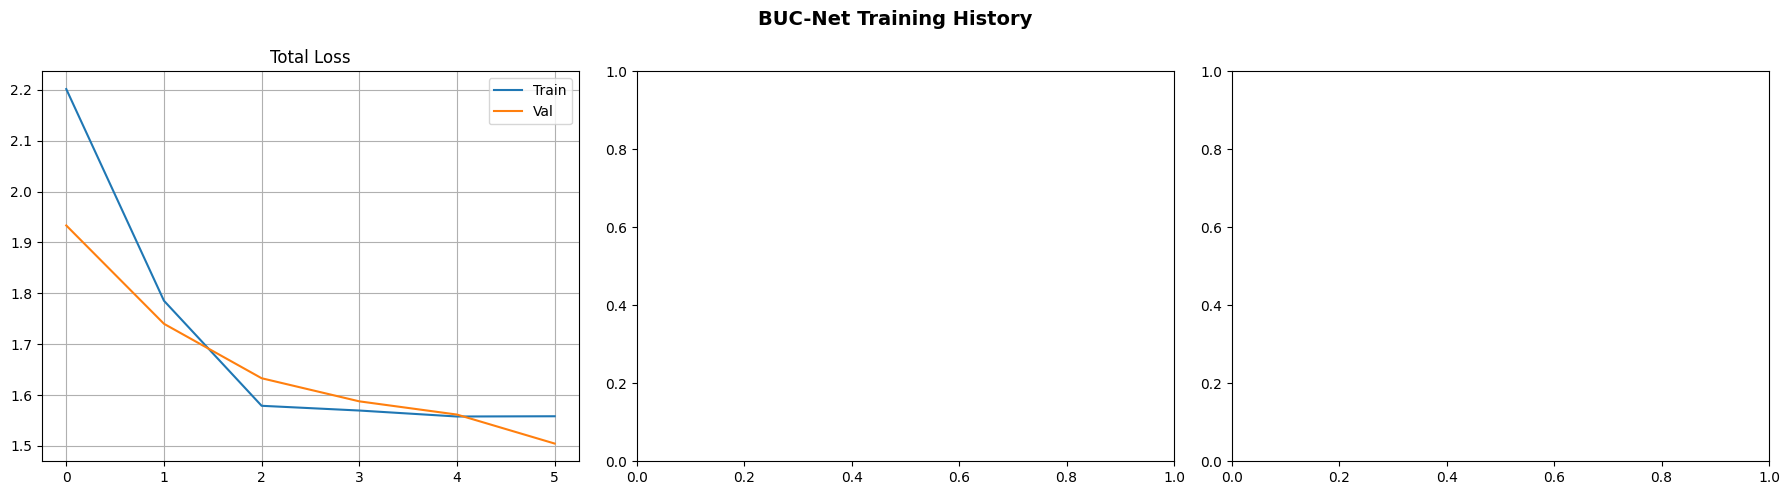

Best model saved: saved_models/buc_net/buc_net_best.keras


In [10]:
# Compile
buc_net.compile(
    optimizer    = optimizers.RMSprop(learning_rate=LEARNING_RATE),
    loss         = [stage1_loss, stage2_loss],
    loss_weights = [1.0, 1.0],
    metrics      = [
        tf.keras.metrics.CategoricalAccuracy(name='s1_acc'),
        tf.keras.metrics.CategoricalAccuracy(name='s2_acc'),
    ]
)
print(f'Compiled: RMSprop(LR={LEARNING_RATE}) | Stage1=DiceCE | Stage2=DiceFocal')

# Build tf.data.Dataset generators (Keras 3 compatible)
train_loader = BUCNetLoader(train_folders, do_augment=True)
val_loader   = BUCNetLoader(val_folders,   do_augment=False)

train_ds, train_steps = train_loader.to_dataset(batch_size=BATCH_SIZE)
val_ds,   val_steps   = val_loader.to_dataset(batch_size=BATCH_SIZE)

ckpt_path = os.path.join(SAVE_DIR, 'buc_net_best.keras')
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_loss',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=30,
                  restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(SAVE_DIR, 'training_log.csv'), append=True),
]

print(f'Training for up to {EPOCHS} epochs...')
history = buc_net.fit(
    train_ds,
    validation_data  = val_ds,
    epochs           = EPOCHS,
    steps_per_epoch  = train_steps,
    # steps_per_epoch  = 4,
    validation_steps = val_steps,
    callbacks        = callbacks,
    verbose          = 1
)

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BUC-Net Training History', fontsize=14, fontweight='bold')
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(True)
for idx, (key, title) in enumerate([('s1_acc','Stage 1 Acc'),('s2_acc','Stage 2 Acc')], 1):
    if key in history.history:
        axes[idx].plot(history.history[key],           label='Train')
        axes[idx].plot(history.history[f'val_{key}'],  label='Val')
        axes[idx].set_title(title); axes[idx].legend(); axes[idx].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best model saved: {ckpt_path}')


## Cell 10 — Gaussian Sliding-Window Inference

In [11]:
def create_gaussian_importance_map(patch_shape, sigma_scale=0.125):
    """
    3D Gaussian weight map centered on patch.
    Paper: 'used Gaussian fusion to generate full-resolution segmentation results'
    Center voxels trusted more than edges -> reduces boundary stitching artifacts.
    """
    weight = np.ones(patch_shape, dtype=np.float64)
    for dim, size in enumerate(patch_shape):
        center  = size / 2.0
        sigma   = max(size * sigma_scale, 1.0)
        coords  = np.arange(size, dtype=np.float64)
        g1d     = np.exp(-0.5 * ((coords - center) / sigma) ** 2)
        shape_bc        = [1, 1, 1]
        shape_bc[dim]   = size
        weight *= g1d.reshape(shape_bc)
    return weight.astype(np.float32)


def predict_volume_gaussian(model, volume, patch_shape=PATCH_SIZE,
                             stride=STRIDE, num_classes=NUM_CLASSES,
                             infer_batch=2):
    """
    Full-volume Gaussian-weighted sliding-window inference.
    Returns both Stage 1 (coarse) and Stage 2 (refined) probability maps.

    Args:
        model:       BUC-Net with 2 outputs [coarse, refined]
        volume:      (H,W,D,C) float32 normalized MRI
        patch_shape: (pH,pW,pD) must match training patch size
        stride:      (sH,sW,sD) sliding step
        infer_batch: patches per forward pass (reduce if OOM)
    Returns:
        (coarse_prob, refined_prob): both (H,W,D,num_classes)
    """
    H, W, D, C = volume.shape
    pH, pW, pD = patch_shape
    sH, sW, sD = stride

    # Pad if volume smaller than patch in any dim
    pH2 = max(pH, H); pW2 = max(pW, W); pD2 = max(pD, D)
    pad = [(0, max(pH - H, 0)), (0, max(pW - W, 0)),
           (0, max(pD - D, 0)), (0, 0)]
    if any(p > 0 for row in pad for p in row):
        volume = np.pad(volume, pad, mode='constant')
    Hp, Wp, Dp, _ = volume.shape

    def starts(sz, ps, s):
        st = list(range(0, max(sz - ps, 0) + 1, s))
        if not st or st[-1] + ps < sz:
            st.append(max(sz - ps, 0))
        return sorted(set(st))

    coords_all = [(h,w,d) for h in starts(Hp,pH,sH)
                           for w in starts(Wp,pW,sW)
                           for d in starts(Dp,pD,sD)]

    coarse_acc  = np.zeros((Hp, Wp, Dp, num_classes), np.float64)
    refined_acc = np.zeros((Hp, Wp, Dp, num_classes), np.float64)
    weight_sum  = np.zeros((Hp, Wp, Dp), np.float64)
    gauss       = create_gaussian_importance_map(patch_shape).astype(np.float64)

    print(f'  Sliding-window: {len(coords_all)} patches ({len(starts(Hp,pH,sH))}x{len(starts(Wp,pW,sW))}x{len(starts(Dp,pD,sD))})')

    for b0 in range(0, len(coords_all), infer_batch):
        batch_c = coords_all[b0:b0+infer_batch]
        batch_p = np.array([volume[h:h+pH, w:w+pW, d:d+pD] for h,w,d in batch_c], np.float32)
        c_pred, r_pred = model.predict(batch_p, verbose=0)
        for i, (h,w,d) in enumerate(batch_c):
            g4 = gauss[..., np.newaxis]
            coarse_acc [h:h+pH, w:w+pW, d:d+pD] += c_pred[i] * g4
            refined_acc[h:h+pH, w:w+pW, d:d+pD] += r_pred[i] * g4
            weight_sum [h:h+pH, w:w+pW, d:d+pD] += gauss

    ws = np.maximum(weight_sum, 1e-8)[..., np.newaxis]
    coarse_prob  = (coarse_acc  / ws).astype(np.float32)[:H,:W,:D]
    refined_prob = (refined_acc / ws).astype(np.float32)[:H,:W,:D]
    print(f'  Inference complete -> {refined_prob.shape}')
    return coarse_prob, refined_prob


# Test with dummy volume
_vol = np.zeros((240, 240, 155, CHANNELS), np.float32)
print('Testing inference pipeline...')
_cp, _rp = predict_volume_gaussian(buc_net, _vol, infer_batch=2)
print(f'Coarse:{_cp.shape} Refined:{_rp.shape}')
del _vol, _cp, _rp


Testing inference pipeline...
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)
Coarse:(240, 240, 155, 4) Refined:(240, 240, 155, 4)


## Cell 11 — Post-Processing: Largest Connected Component

In [12]:
try:
    from scipy.ndimage import label as scipy_label
    _SCIPY_OK = True
except ImportError:
    _SCIPY_OK = False
    print('scipy not found. Install: pip install scipy')


def keep_largest_cc(binary_mask):
    """Keep only the largest connected component."""
    if not _SCIPY_OK or not np.any(binary_mask):
        return binary_mask
    labeled, n = scipy_label(binary_mask.astype(bool))
    if n == 0:
        return binary_mask
    sizes        = np.bincount(labeled.ravel())
    sizes[0]     = 0
    return (labeled == np.argmax(sizes)).astype(binary_mask.dtype)


def postprocess_prediction(pred_prob_map, apply_lcc=True):
    """
    Argmax + per-class largest connected component.
    Paper: 'post-processed segmentation results by the largest connected component'

    Args:
        pred_prob_map: (H,W,D,C) softmax probabilities
        apply_lcc:     Whether to apply LCC filtering
    Returns:
        seg: (H,W,D) int32 label map {0..3}
    """
    seg = np.argmax(pred_prob_map, axis=-1).astype(np.int32)
    if apply_lcc and _SCIPY_OK:
        refined = np.zeros_like(seg)
        for cls in range(1, pred_prob_map.shape[-1]):
            mask = (seg == cls)
            if np.any(mask):
                mask = keep_largest_cc(mask)
            refined[mask] = cls
        return refined
    return seg


print(f'Post-processing: scipy={_SCIPY_OK} | LCC={("enabled" if _SCIPY_OK else "disabled")}')


Post-processing: scipy=True | LCC=enabled


## Cell 12 — Evaluation Metrics (DSC, HD95, ASD, Precision, Recall)

In [13]:
try:
    from scipy.ndimage import binary_erosion, distance_transform_edt
    _SCIPY_M = True
except ImportError:
    _SCIPY_M = False


def _safe_div(a, b):
    return float(a)/float(b) if float(b) != 0 else float('nan')


def _surf_dist(ma, mb, sp=(1.,1.,1.)):
    """Surface-to-surface distances from ma to mb."""
    if not _SCIPY_M: return np.array([], np.float32)
    ma, mb = ma.astype(bool), mb.astype(bool)
    if not ma.any(): return np.array([], np.float32)
    sa = ma ^ binary_erosion(ma)
    sb = mb ^ binary_erosion(mb) if mb.any() else mb
    if not sb.any(): return np.full(int(sa.sum()), np.inf, np.float32)
    return distance_transform_edt(~sb, sampling=sp)[sa].astype(np.float32)


def dice_score(y_true_seg, y_pred_seg, cls):
    t  = (y_true_seg == cls).ravel().astype(np.uint8)
    p  = (y_pred_seg == cls).ravel().astype(np.uint8)
    tp = int((t & p).sum())
    return _safe_div(2*tp, int(t.sum()) + int(p.sum()))


def hd95(t, p, sp=(1.,1.,1.)):
    if not _SCIPY_M: return float('nan')
    if not t.any() and not p.any(): return 0.
    if not t.any() or  not p.any(): return float('inf')
    d = np.concatenate([_surf_dist(t,p,sp), _surf_dist(p,t,sp)])
    return float(np.percentile(d, 95)) if len(d) else float('nan')


def asd(t, p, sp=(1.,1.,1.)):
    if not _SCIPY_M: return float('nan')
    if not t.any() and not p.any(): return 0.
    if not t.any() or  not p.any(): return float('inf')
    d1, d2 = _surf_dist(t,p,sp), _surf_dist(p,t,sp)
    n = len(d1)+len(d2)
    return float((d1.sum()+d2.sum())/n) if n else float('nan')


def compute_all_metrics(y_true, y_pred, sp=(1.,1.,1.), n=NUM_CLASSES):
    """Compute DSC, HD95, ASD, Precision, Recall per foreground class."""
    res = {}
    for cls in range(1, n):
        tb, pb = (y_true==cls), (y_pred==cls)
        tp = int((tb & pb).sum())
        fp = int((~tb & pb).sum())
        fn = int((tb & ~pb).sum())
        res[CLASS_NAMES[cls]] = {
            'DSC':       dice_score(y_true, y_pred, cls),
            'HD95_mm':   hd95(tb, pb, sp),
            'ASD_mm':    asd (tb, pb, sp),
            'Precision': _safe_div(tp, tp+fp),
            'Recall':    _safe_div(tp, tp+fn),
        }
    return res


def print_metrics(pid, mdict):
    print(f'\n{"-"*60}')
    print(f'  Patient: {pid}')
    print(f'  {"Class":<13} {"DSC":>7} {"HD95(mm)":>10} {"ASD(mm)":>9} {"Prec":>8} {"Recall":>8}')
    print(f'  {"-"*58}')
    for cn, m in mdict.items():
        hd = f'{m["HD95_mm"]:10.3f}' if np.isfinite(m['HD95_mm']) else f'{"inf":>10}'
        ad = f'{m["ASD_mm"]:9.3f}'  if np.isfinite(m['ASD_mm'])  else f'{"inf":>9}'
        print(f'  {cn:<13} {m["DSC"]:7.4f} {hd} {ad} {m["Precision"]:8.4f} {m["Recall"]:8.4f}')


print('Metrics defined: DSC, HD95, ASD, Precision, Recall per class')


Metrics defined: DSC, HD95, ASD, Precision, Recall per class


## Cell 13 — Inference on Test Patients + Visualization

Loading best checkpoint: saved_models/buc_net/buc_net_best.keras
Checkpoint loaded.

[1/10] BraTS20_Training_296
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_296
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.1352     75.967    38.841   0.0726   0.9722
  Enhancing      0.0000    141.444   123.073   0.0000   0.0000


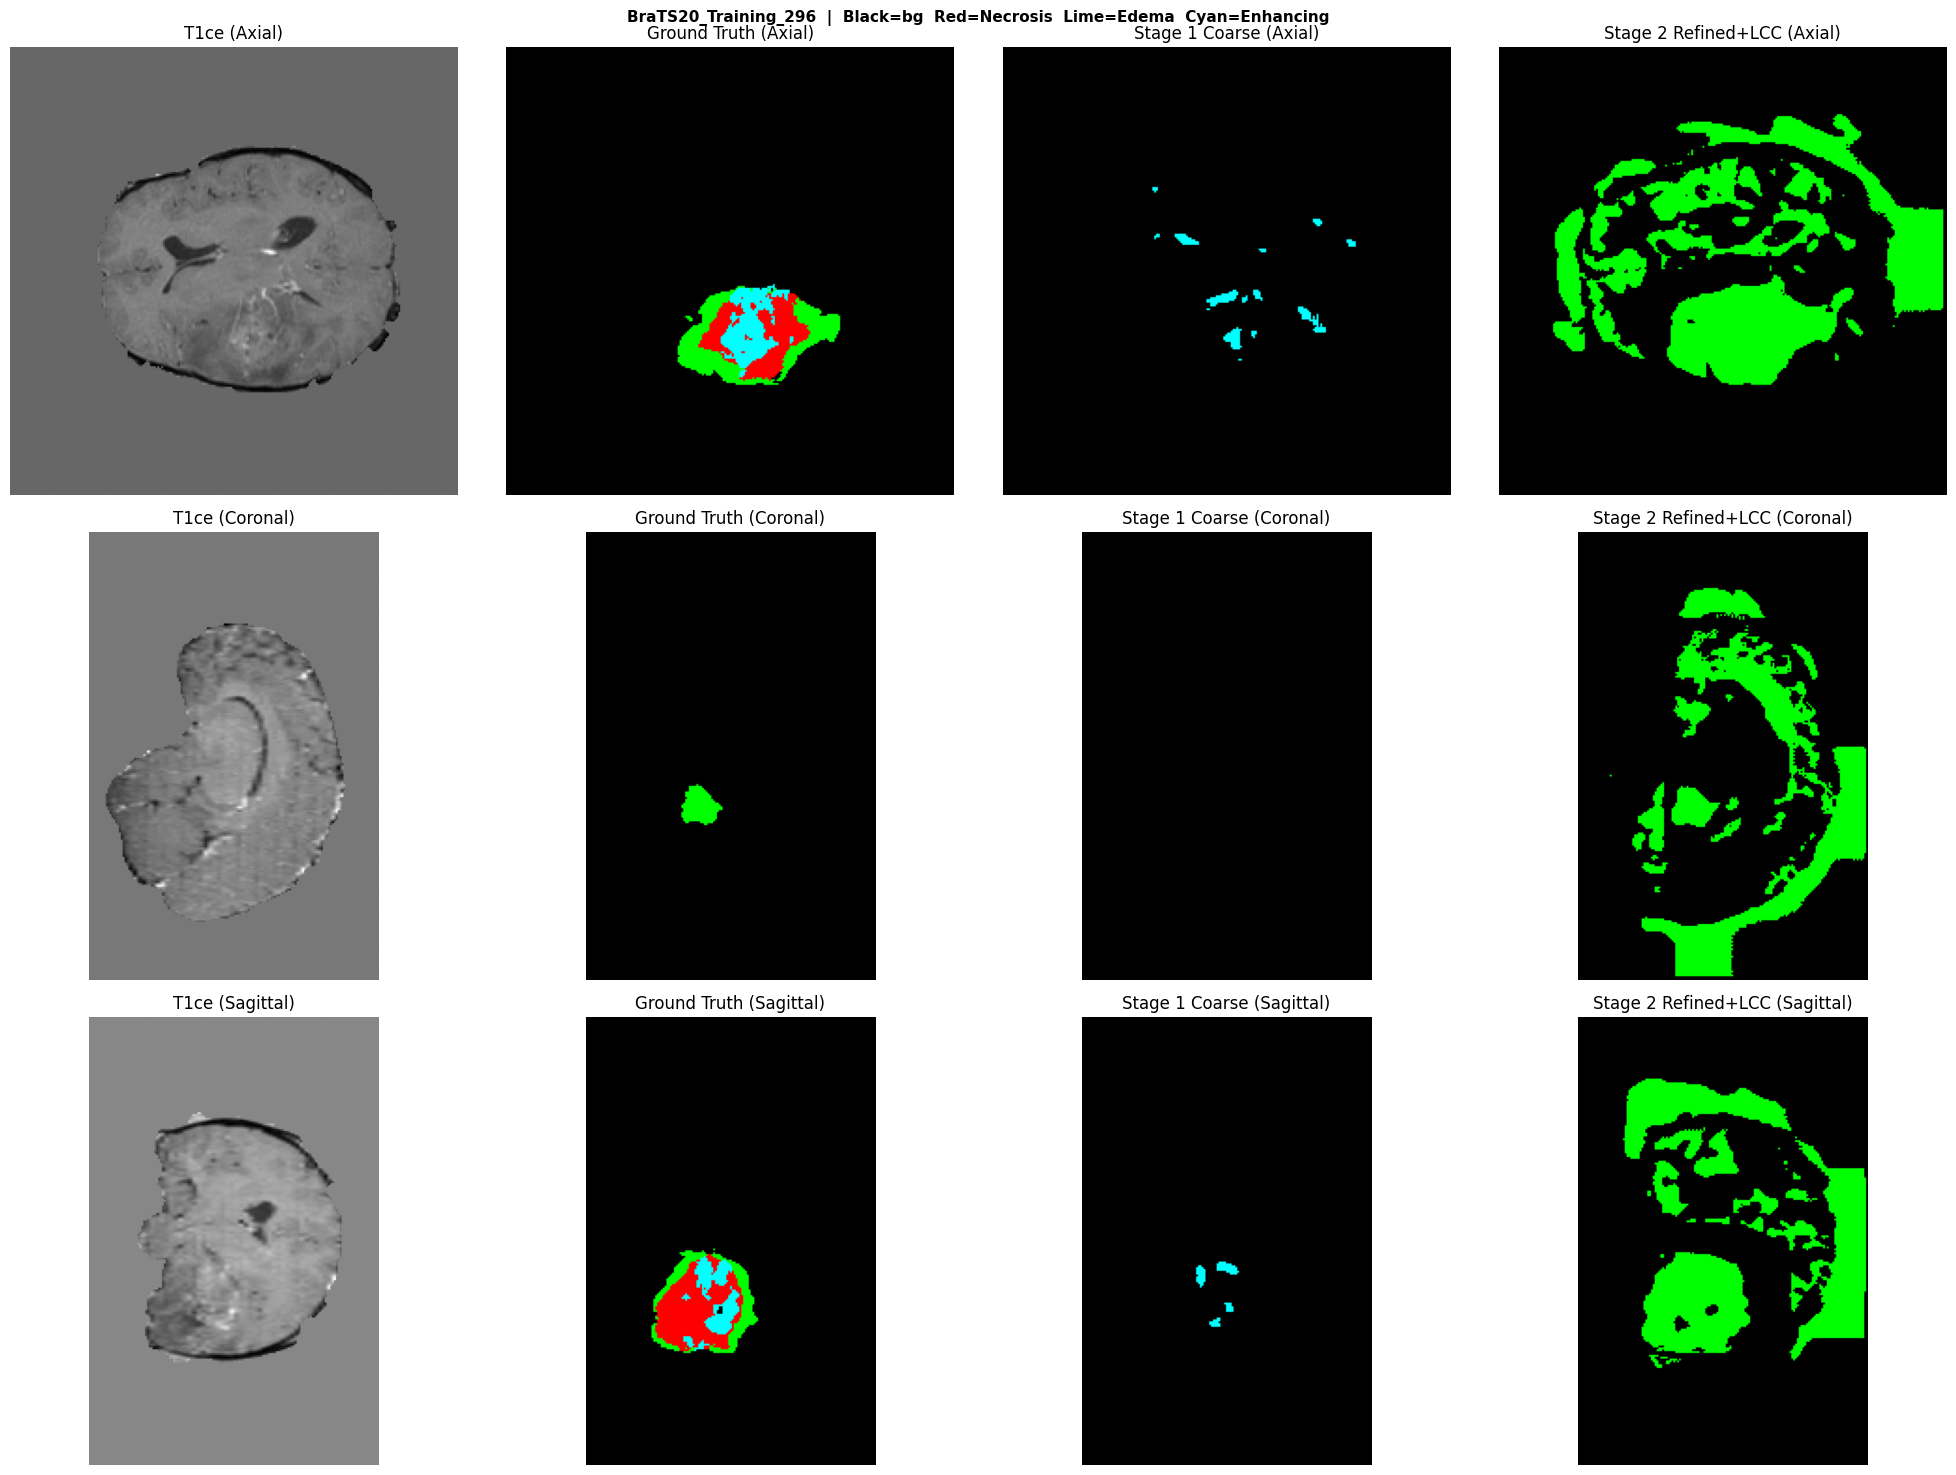


[2/10] BraTS20_Training_297
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_297
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0935     96.732    43.873   0.0491   0.9759
  Enhancing      0.0000        inf       inf   0.0000      nan


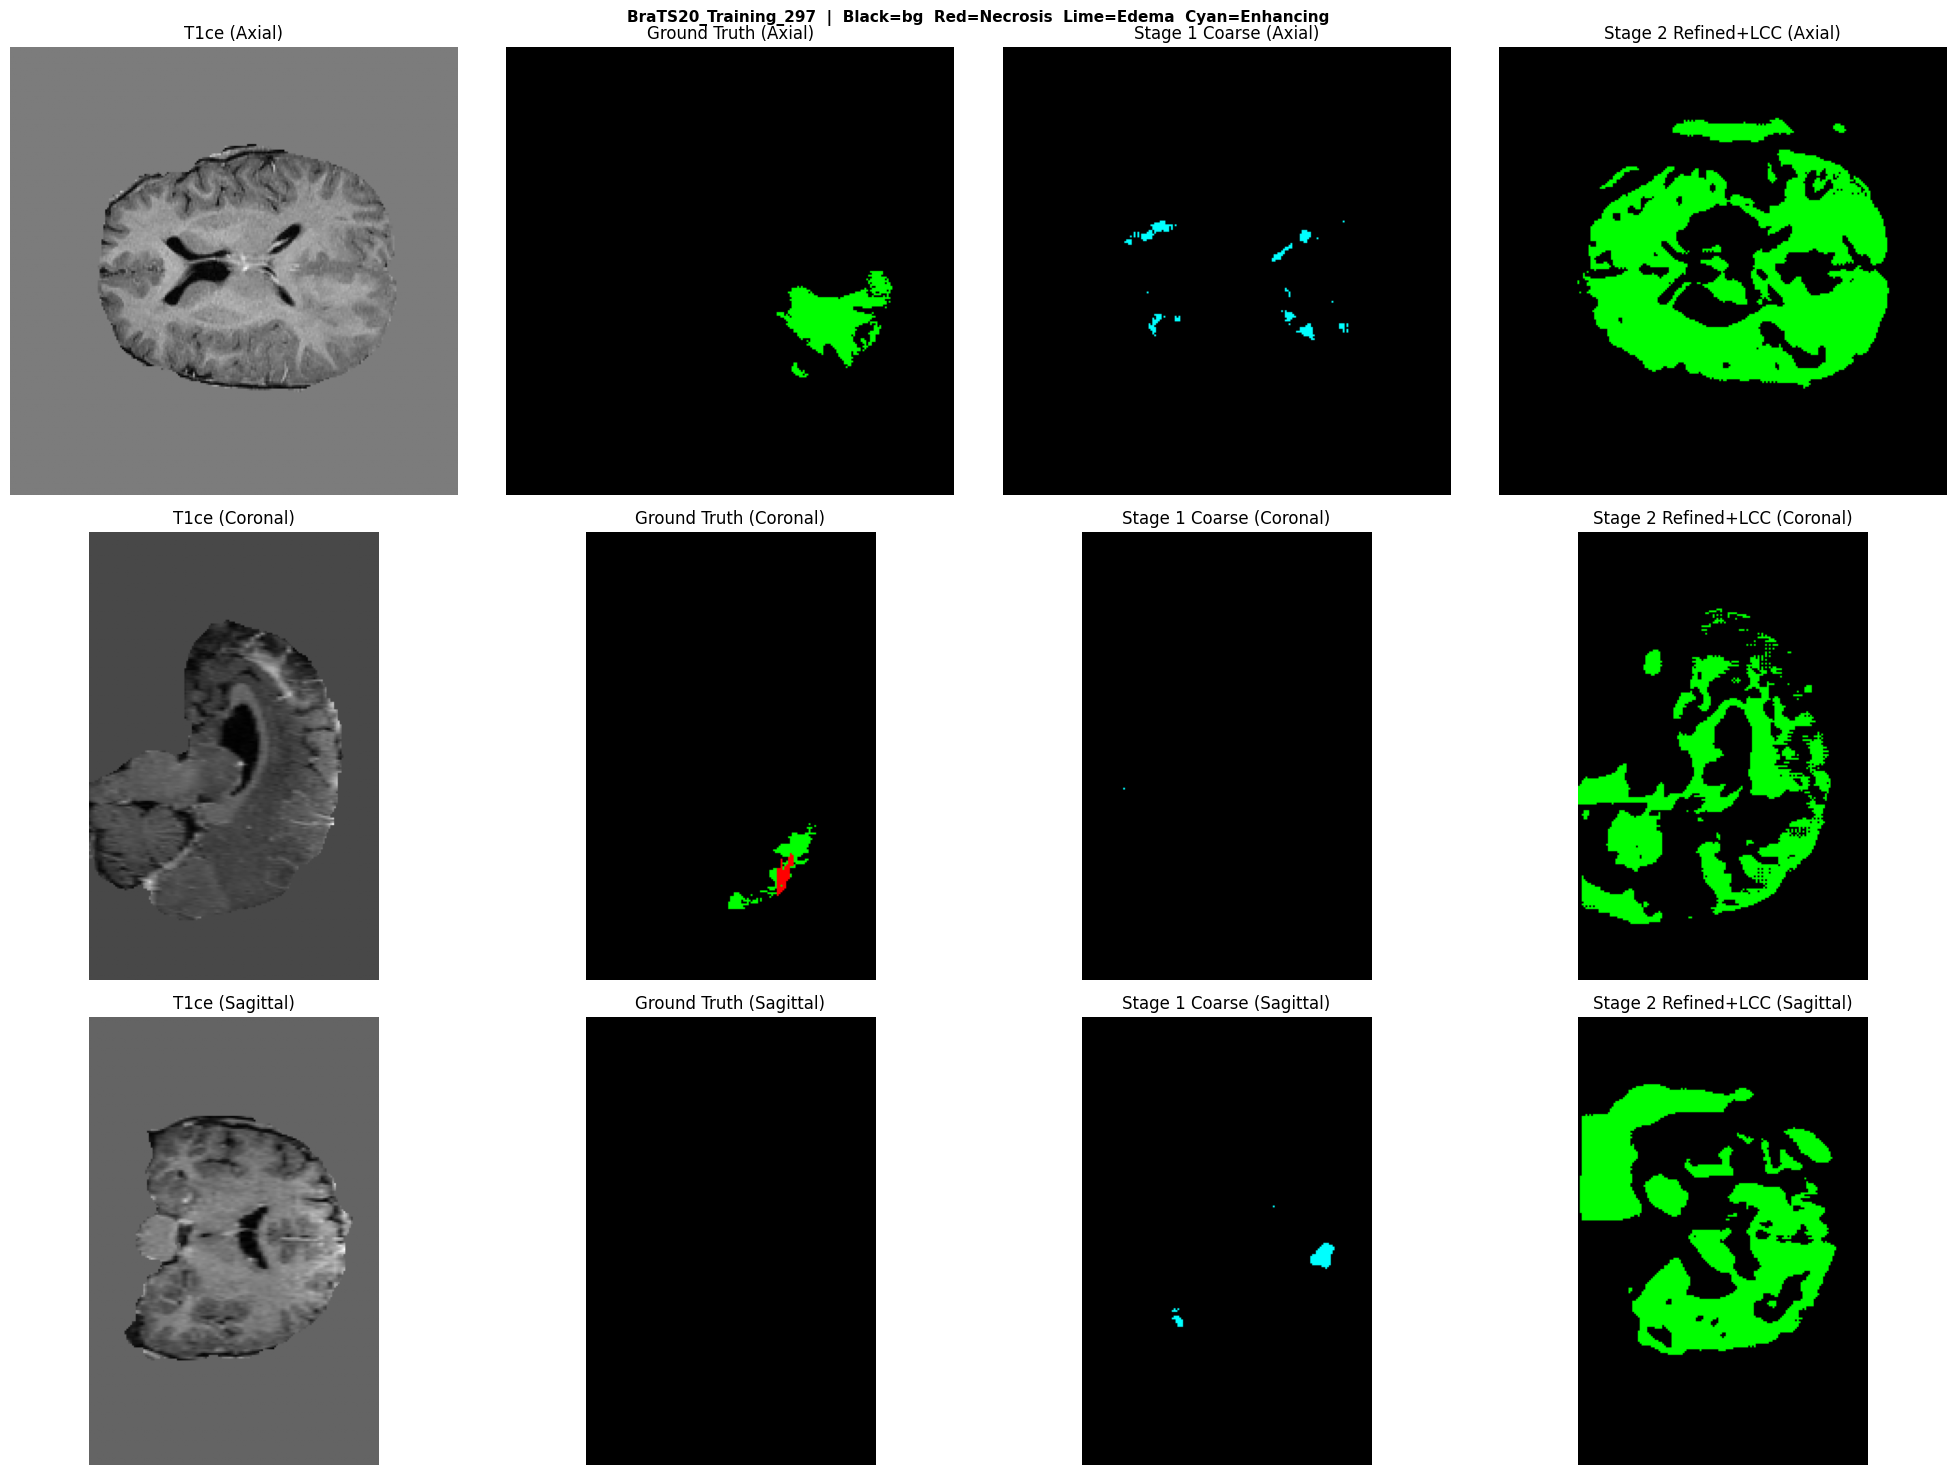


[3/10] BraTS20_Training_298
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_298
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0654     88.876    45.255   0.0338   0.9802
  Enhancing      0.0000    149.302   127.928   0.0000   0.0000


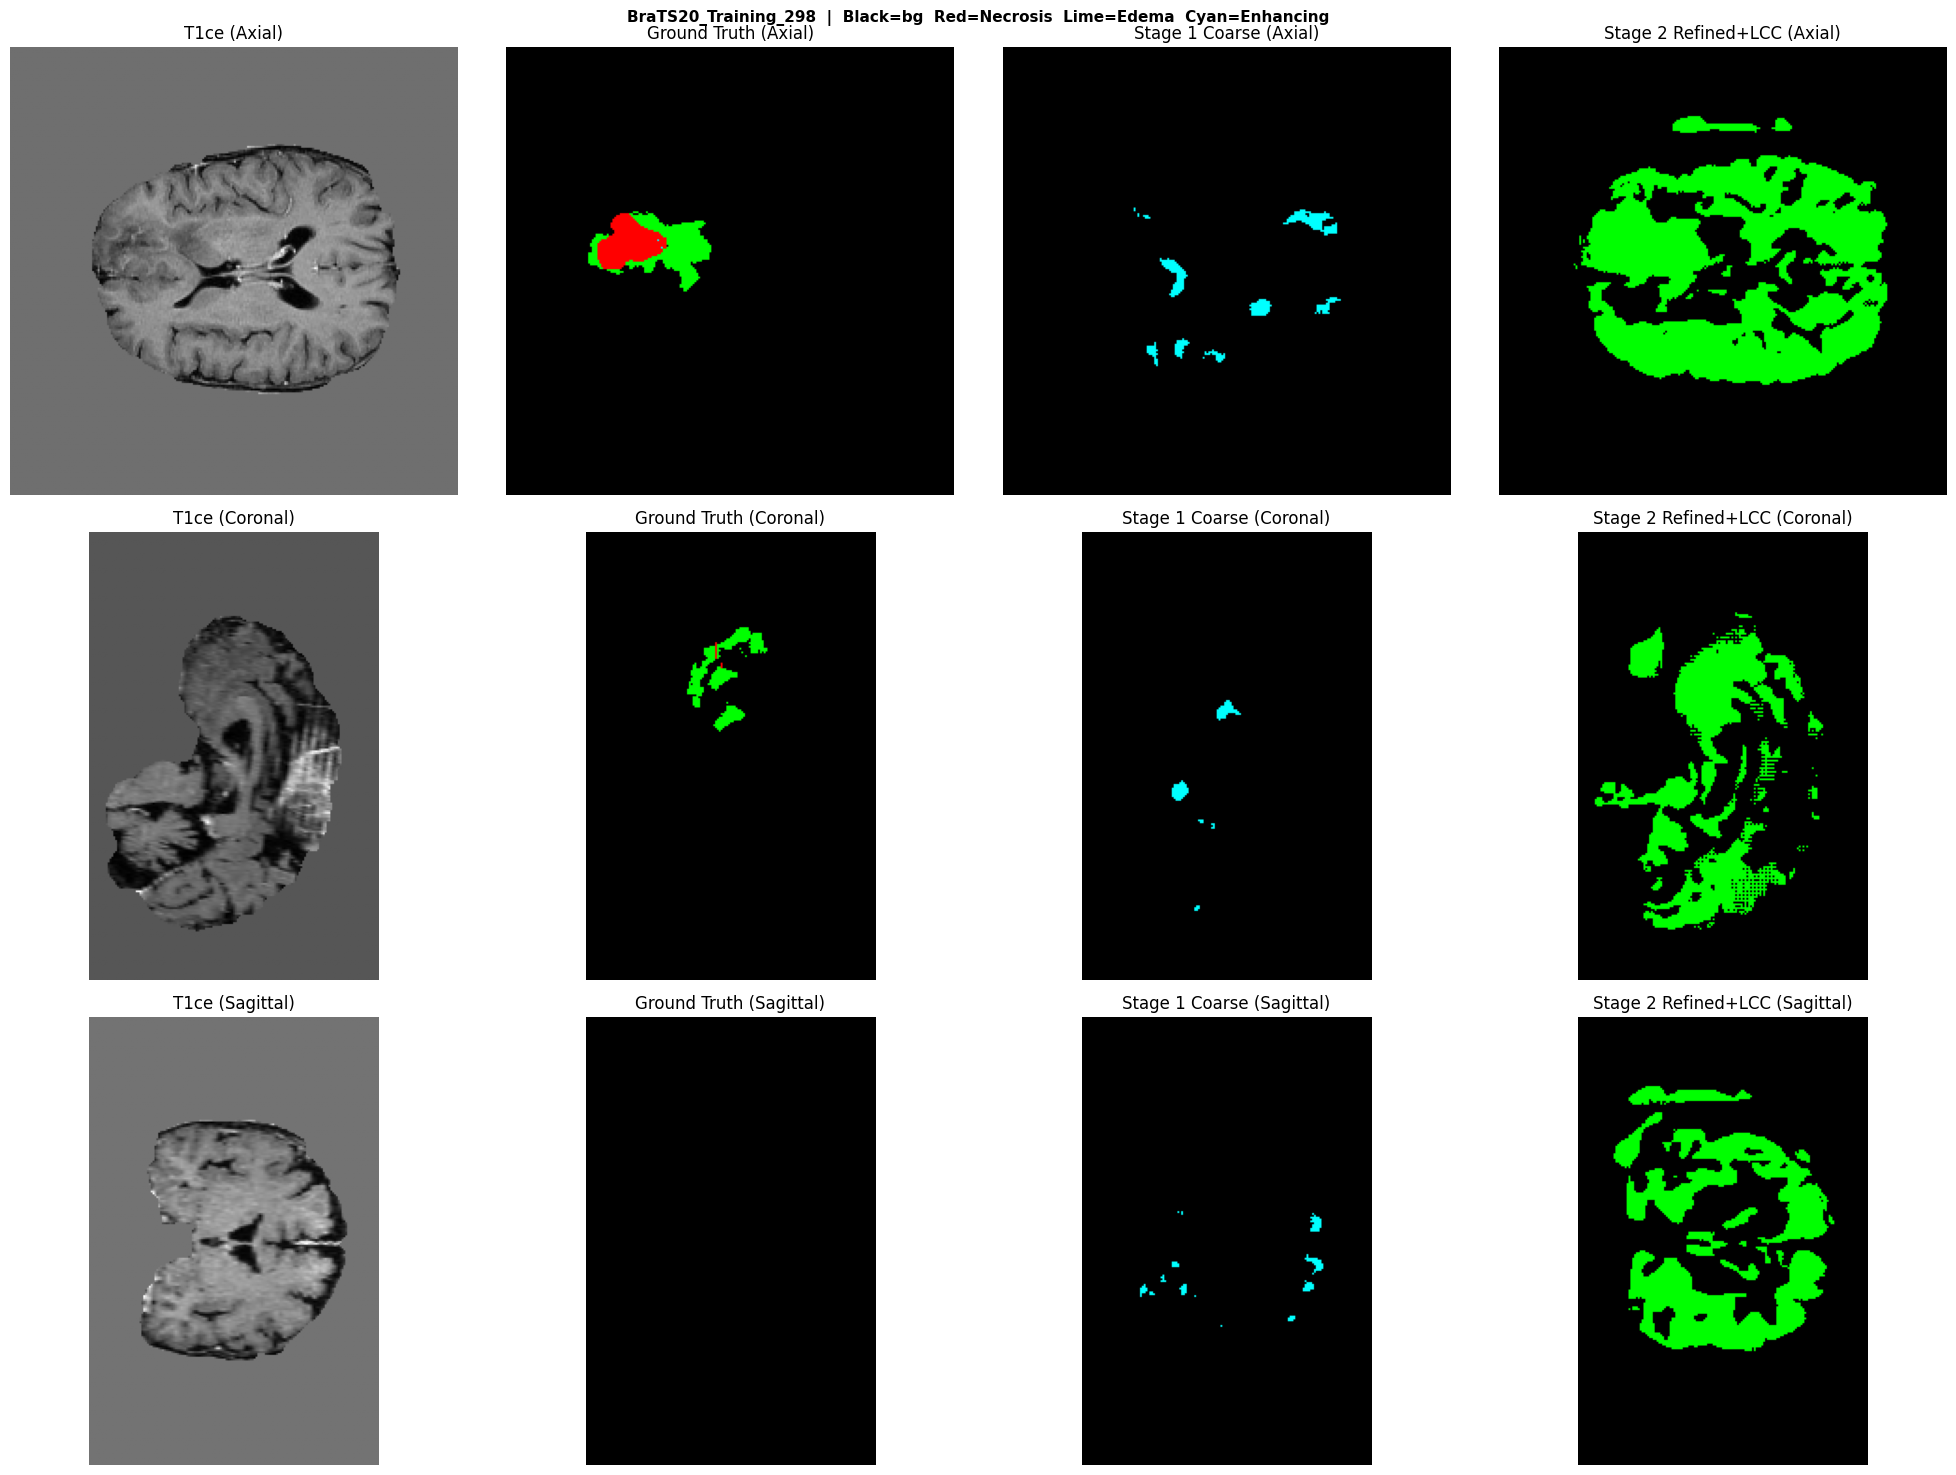


[4/10] BraTS20_Training_299
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_299
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0476     94.599    42.871   0.0244   0.9933
  Enhancing      0.0000    125.675    99.561   0.0000   0.0000


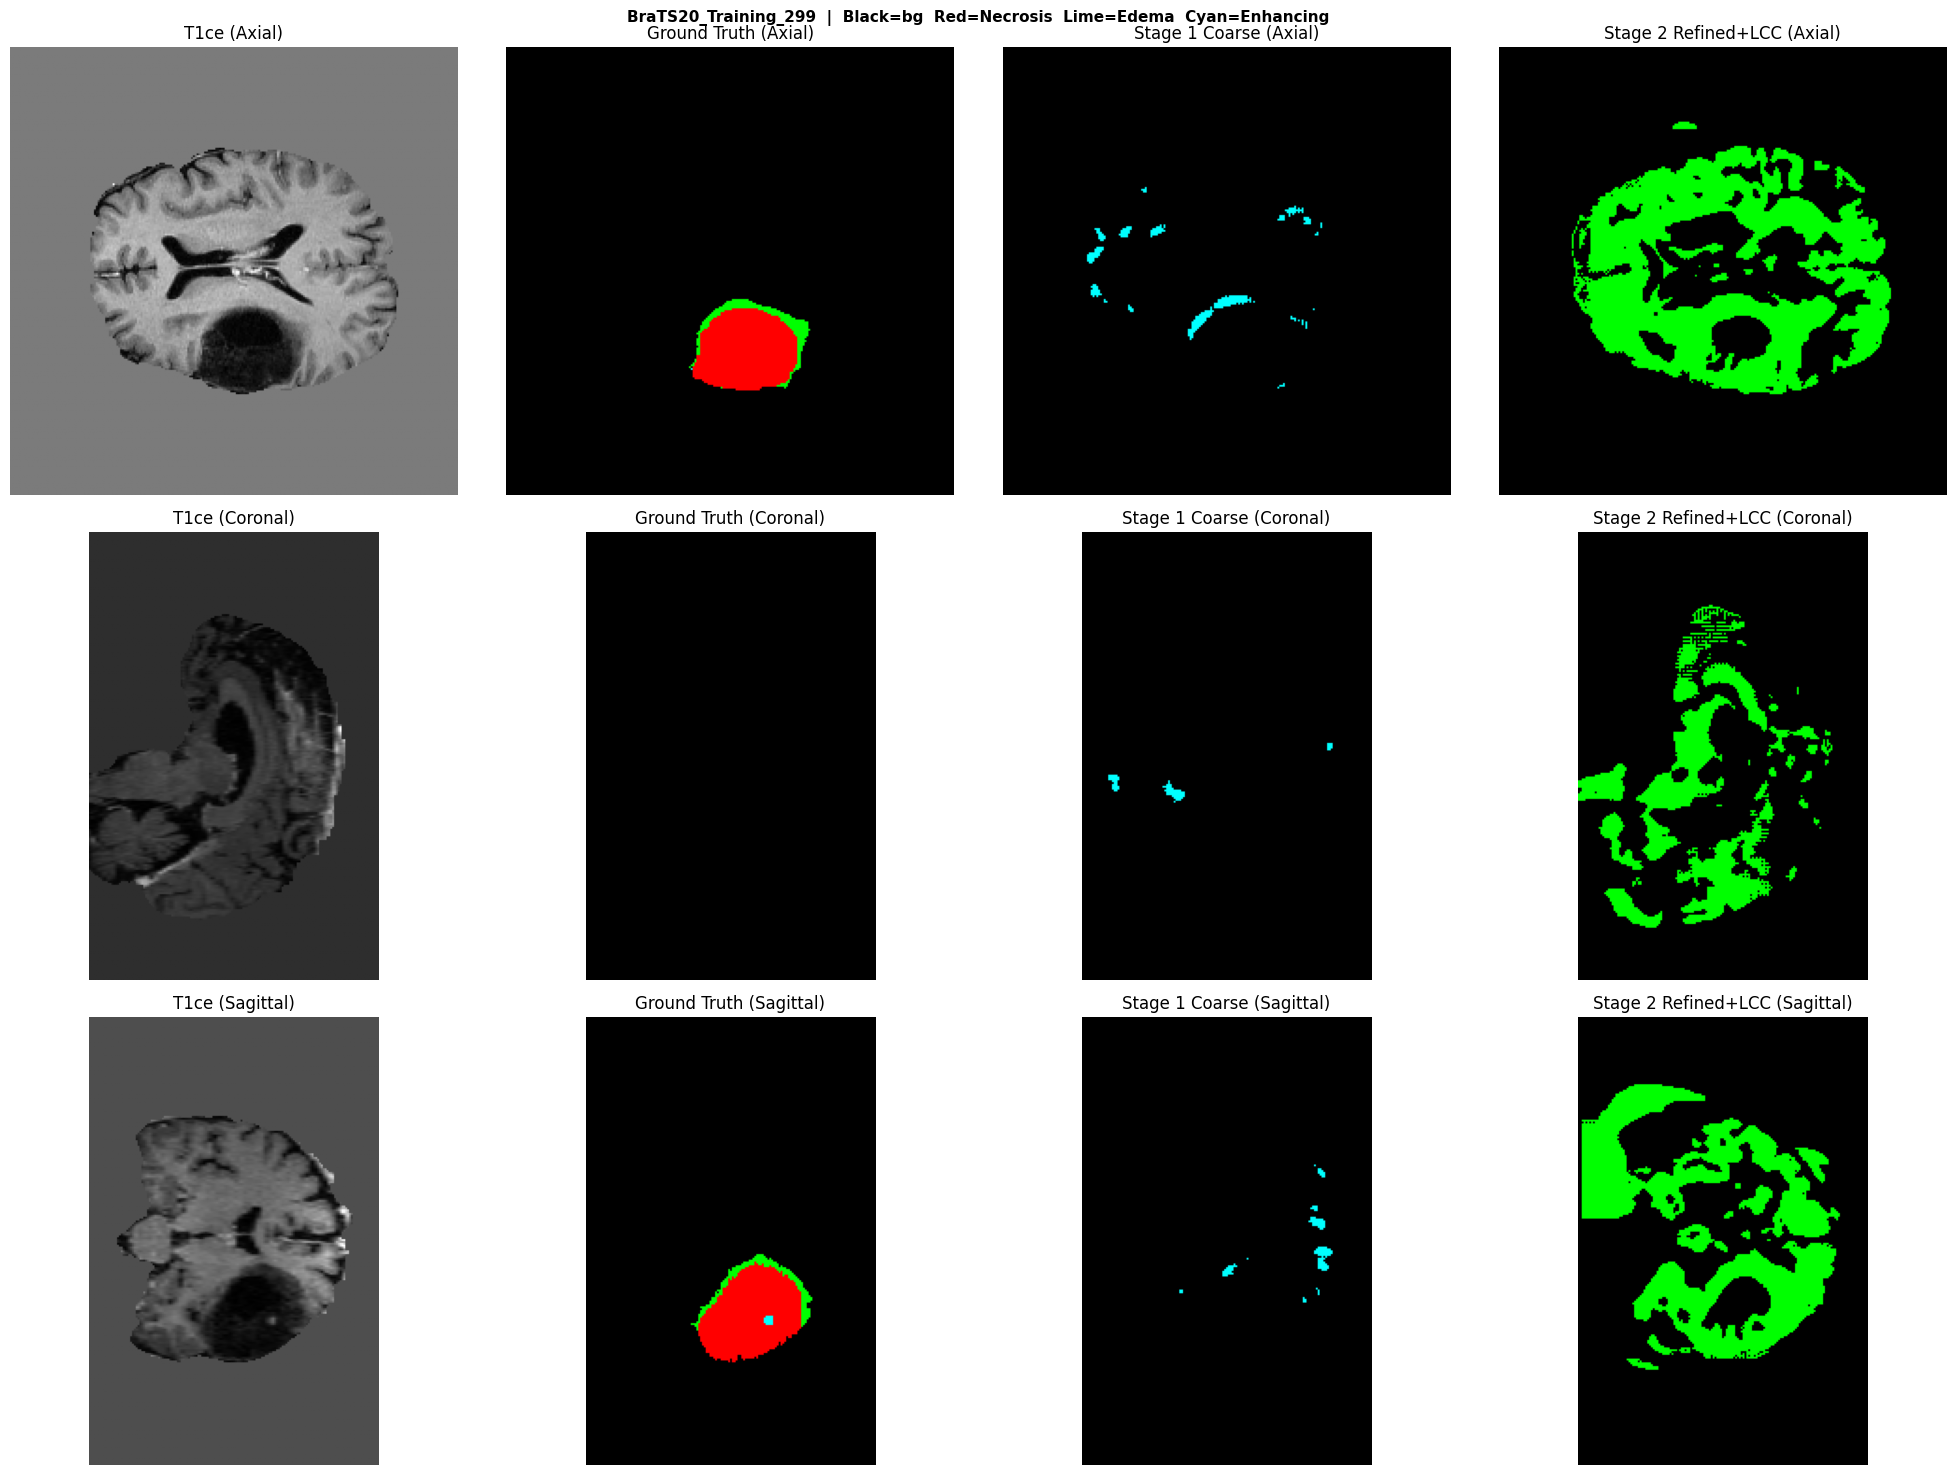


[5/10] BraTS20_Training_300
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_300
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0671     92.563    43.118   0.0347   0.9940
  Enhancing      0.0000    114.977    91.411   0.0000   0.0000


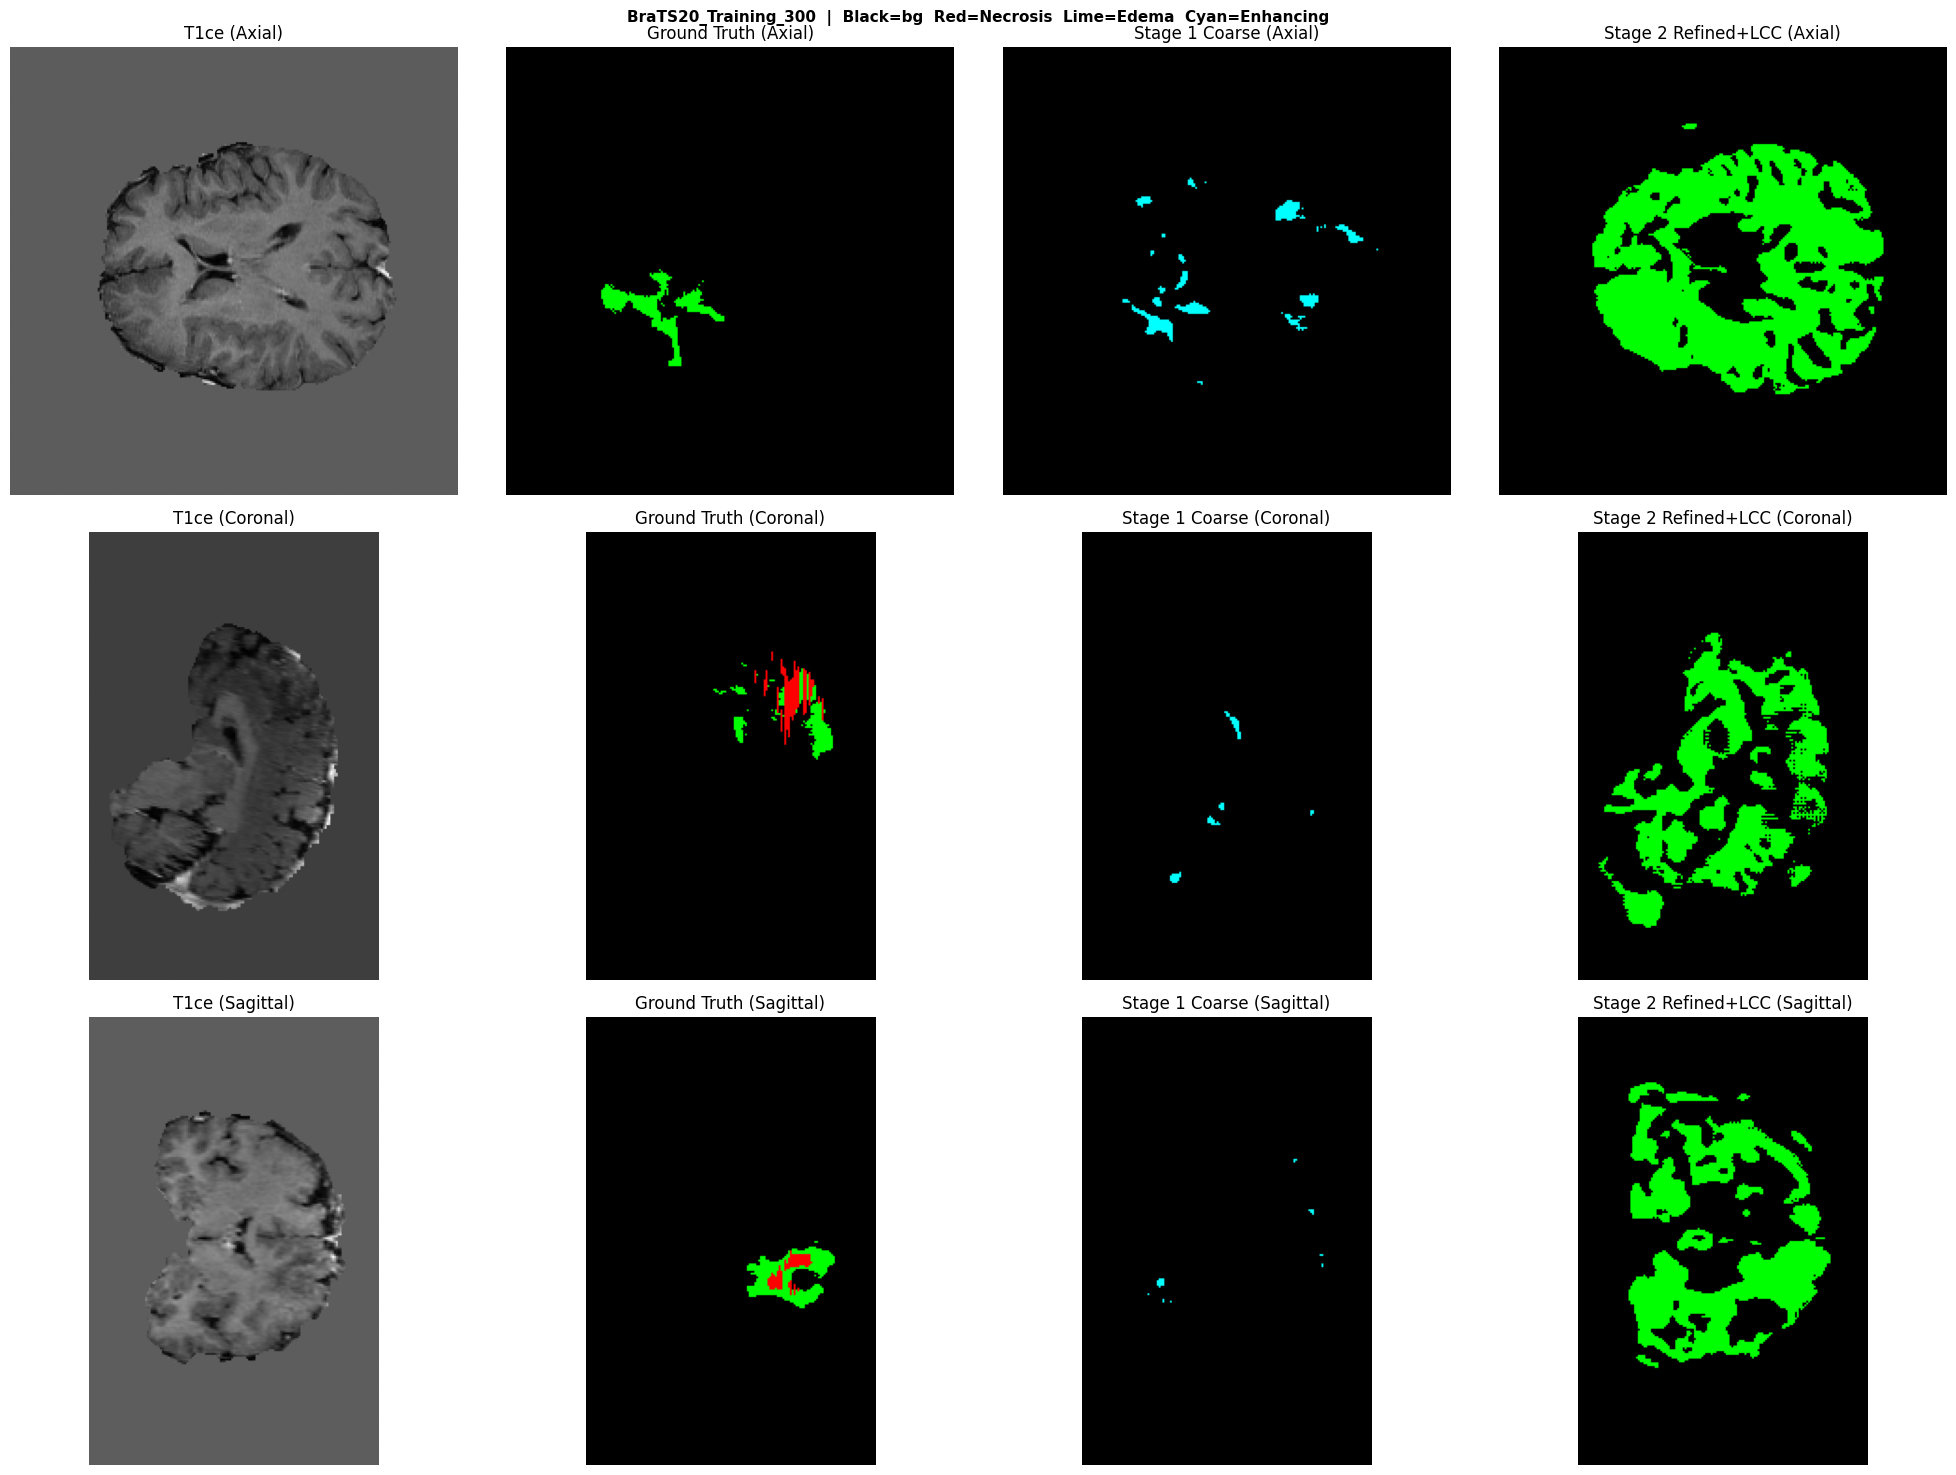


[6/10] BraTS20_Training_301
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_301
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.2167     82.672    32.984   0.1219   0.9743
  Enhancing      0.0000    129.942   102.551   0.0000   0.0000


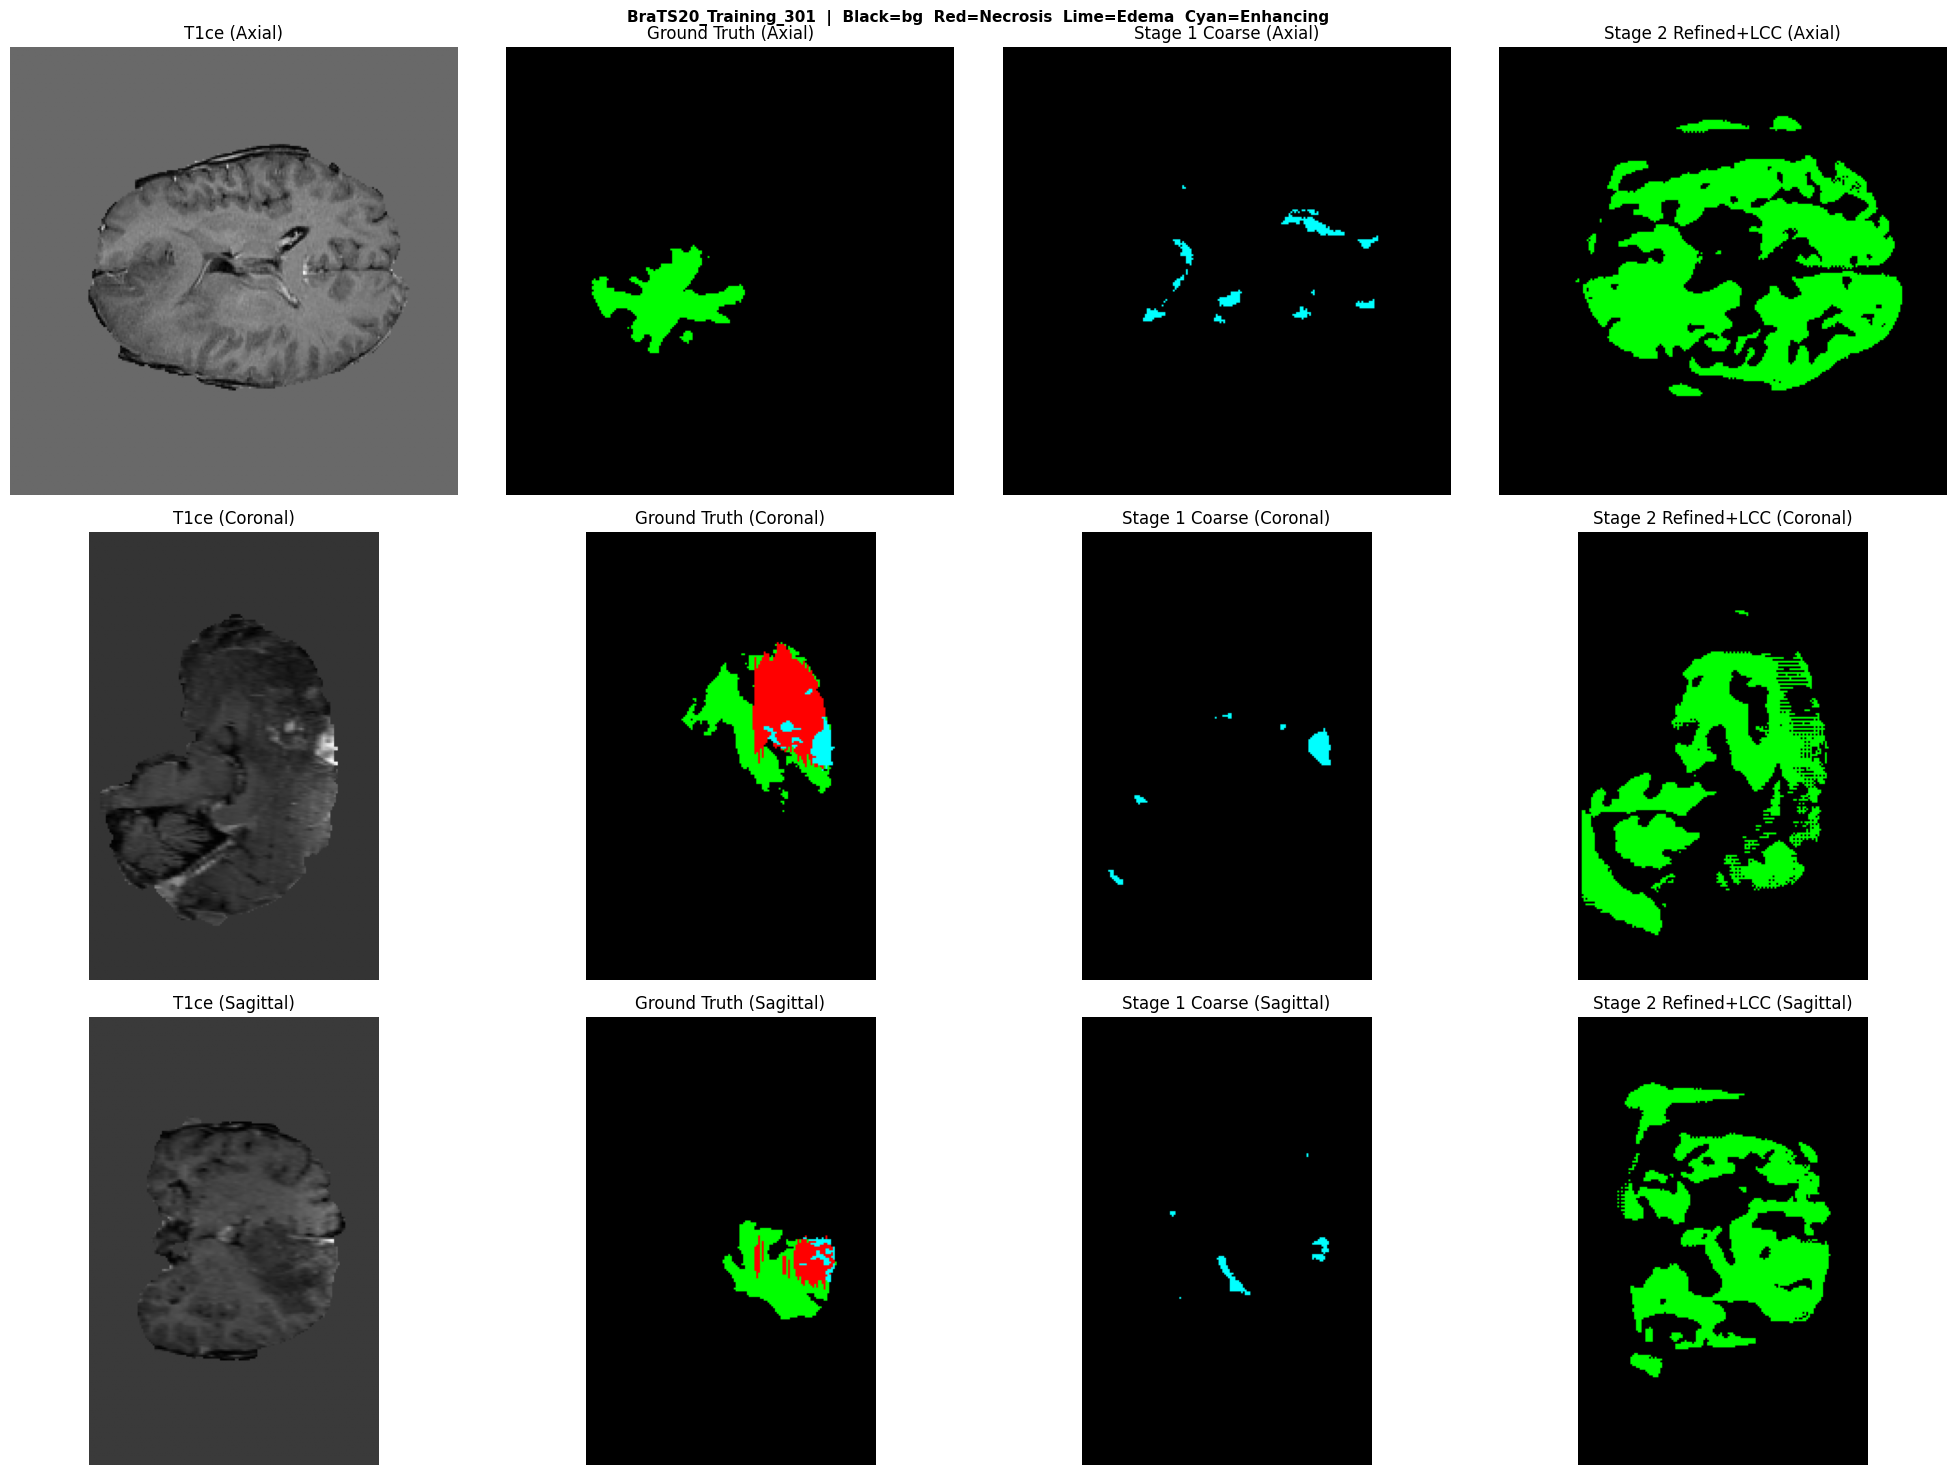


[7/10] BraTS20_Training_302
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_302
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0245     77.724    42.057   0.0125   0.7841
  Enhancing      0.0000    208.711   184.484   0.0000   0.0000


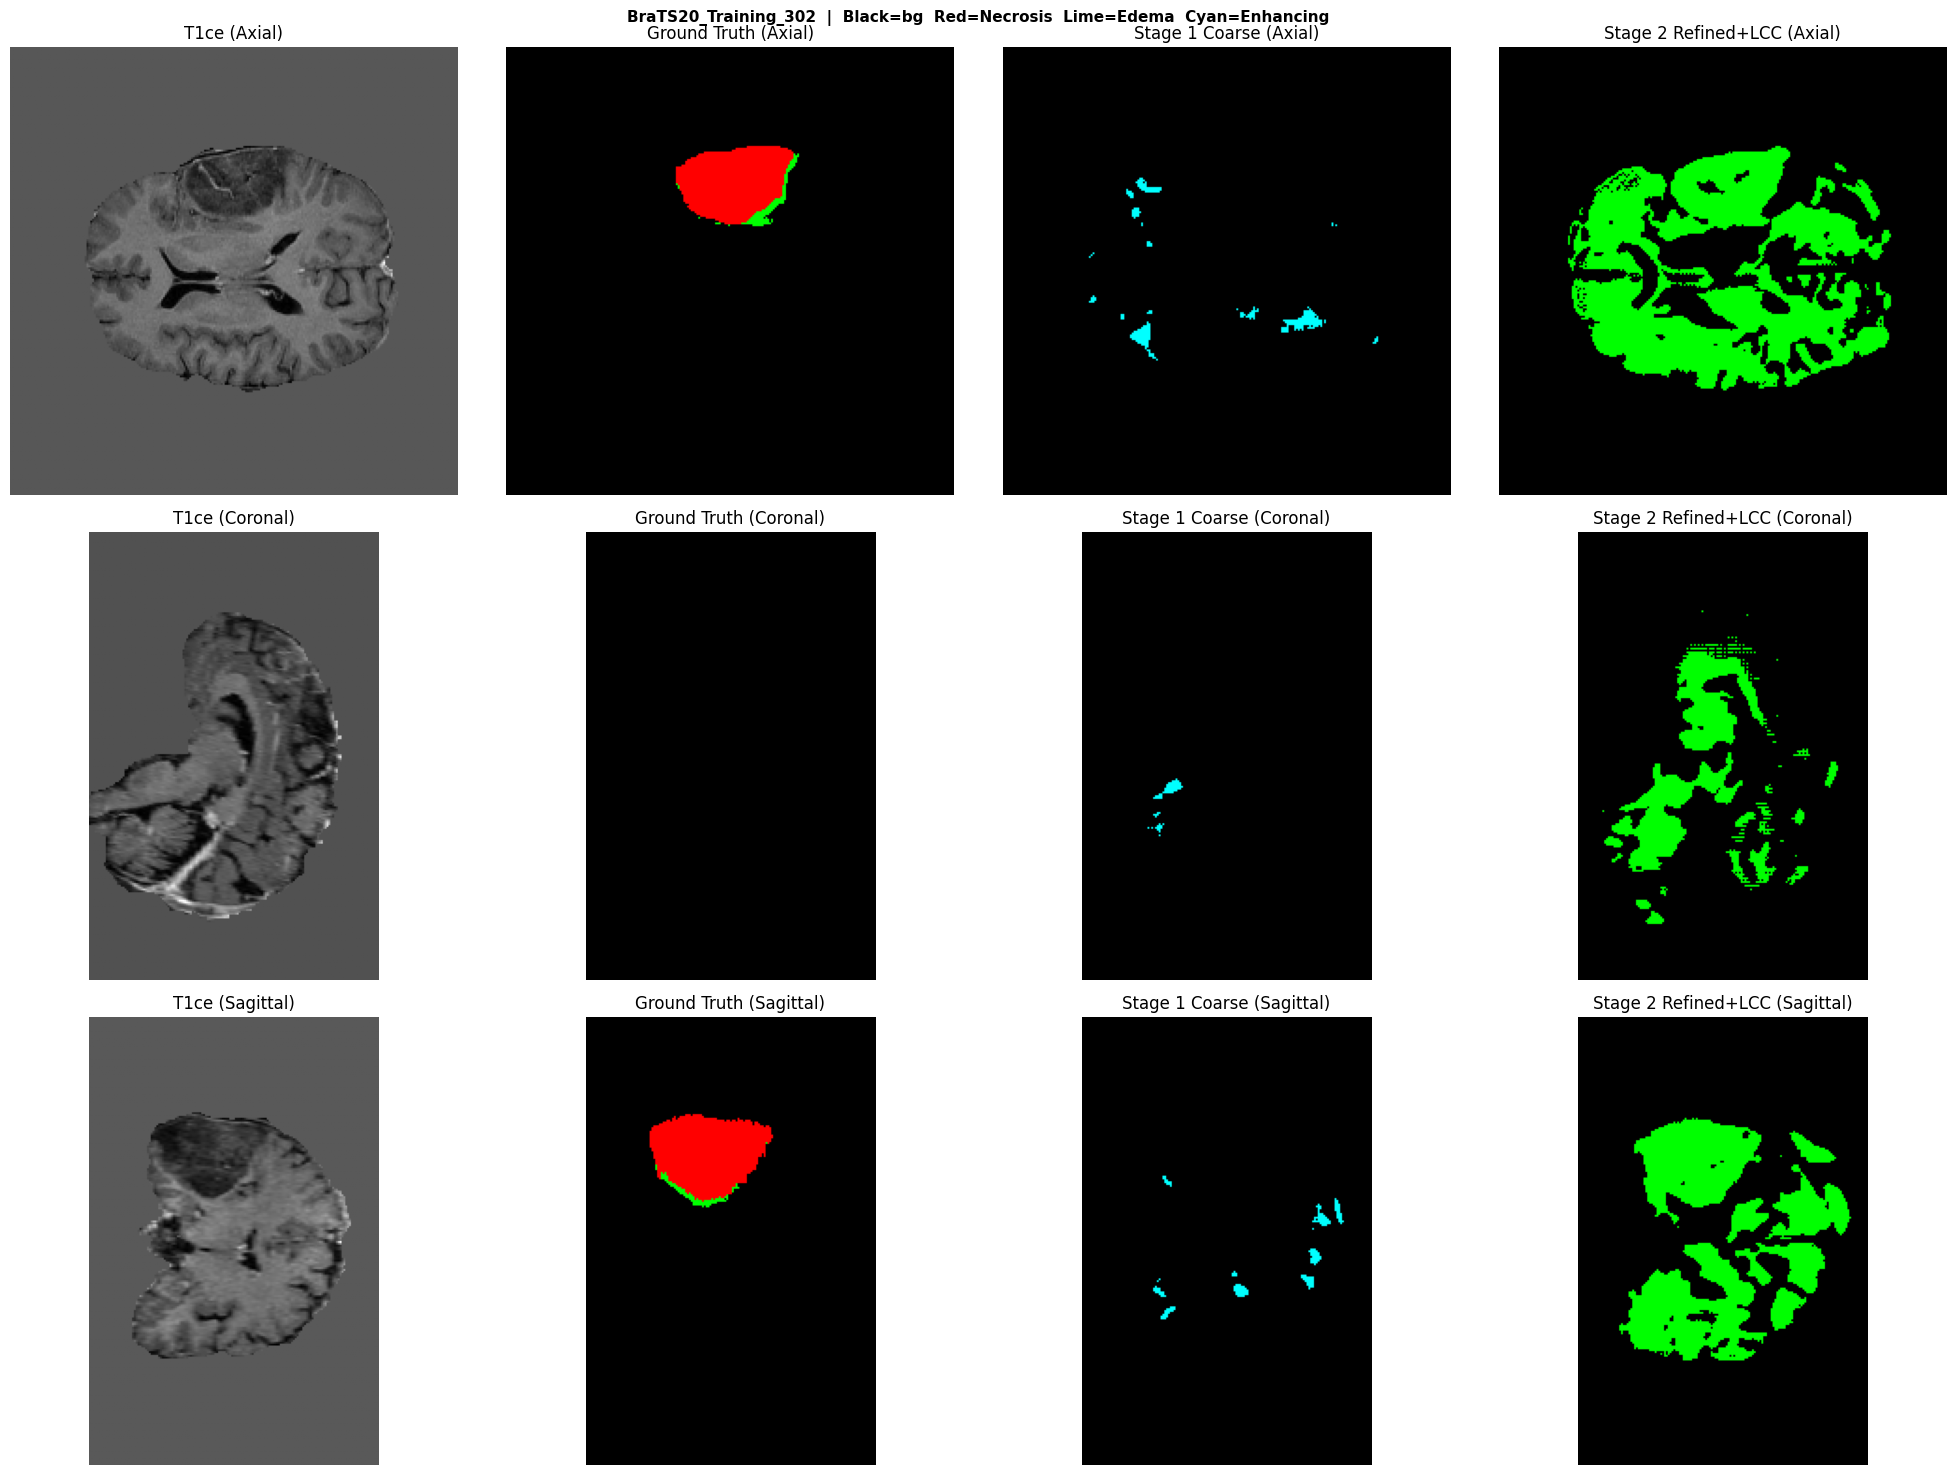


[8/10] BraTS20_Training_303
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_303
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0253    101.995    53.530   0.0128   0.9890
  Enhancing      0.0000    117.801    94.636   0.0000   0.0000


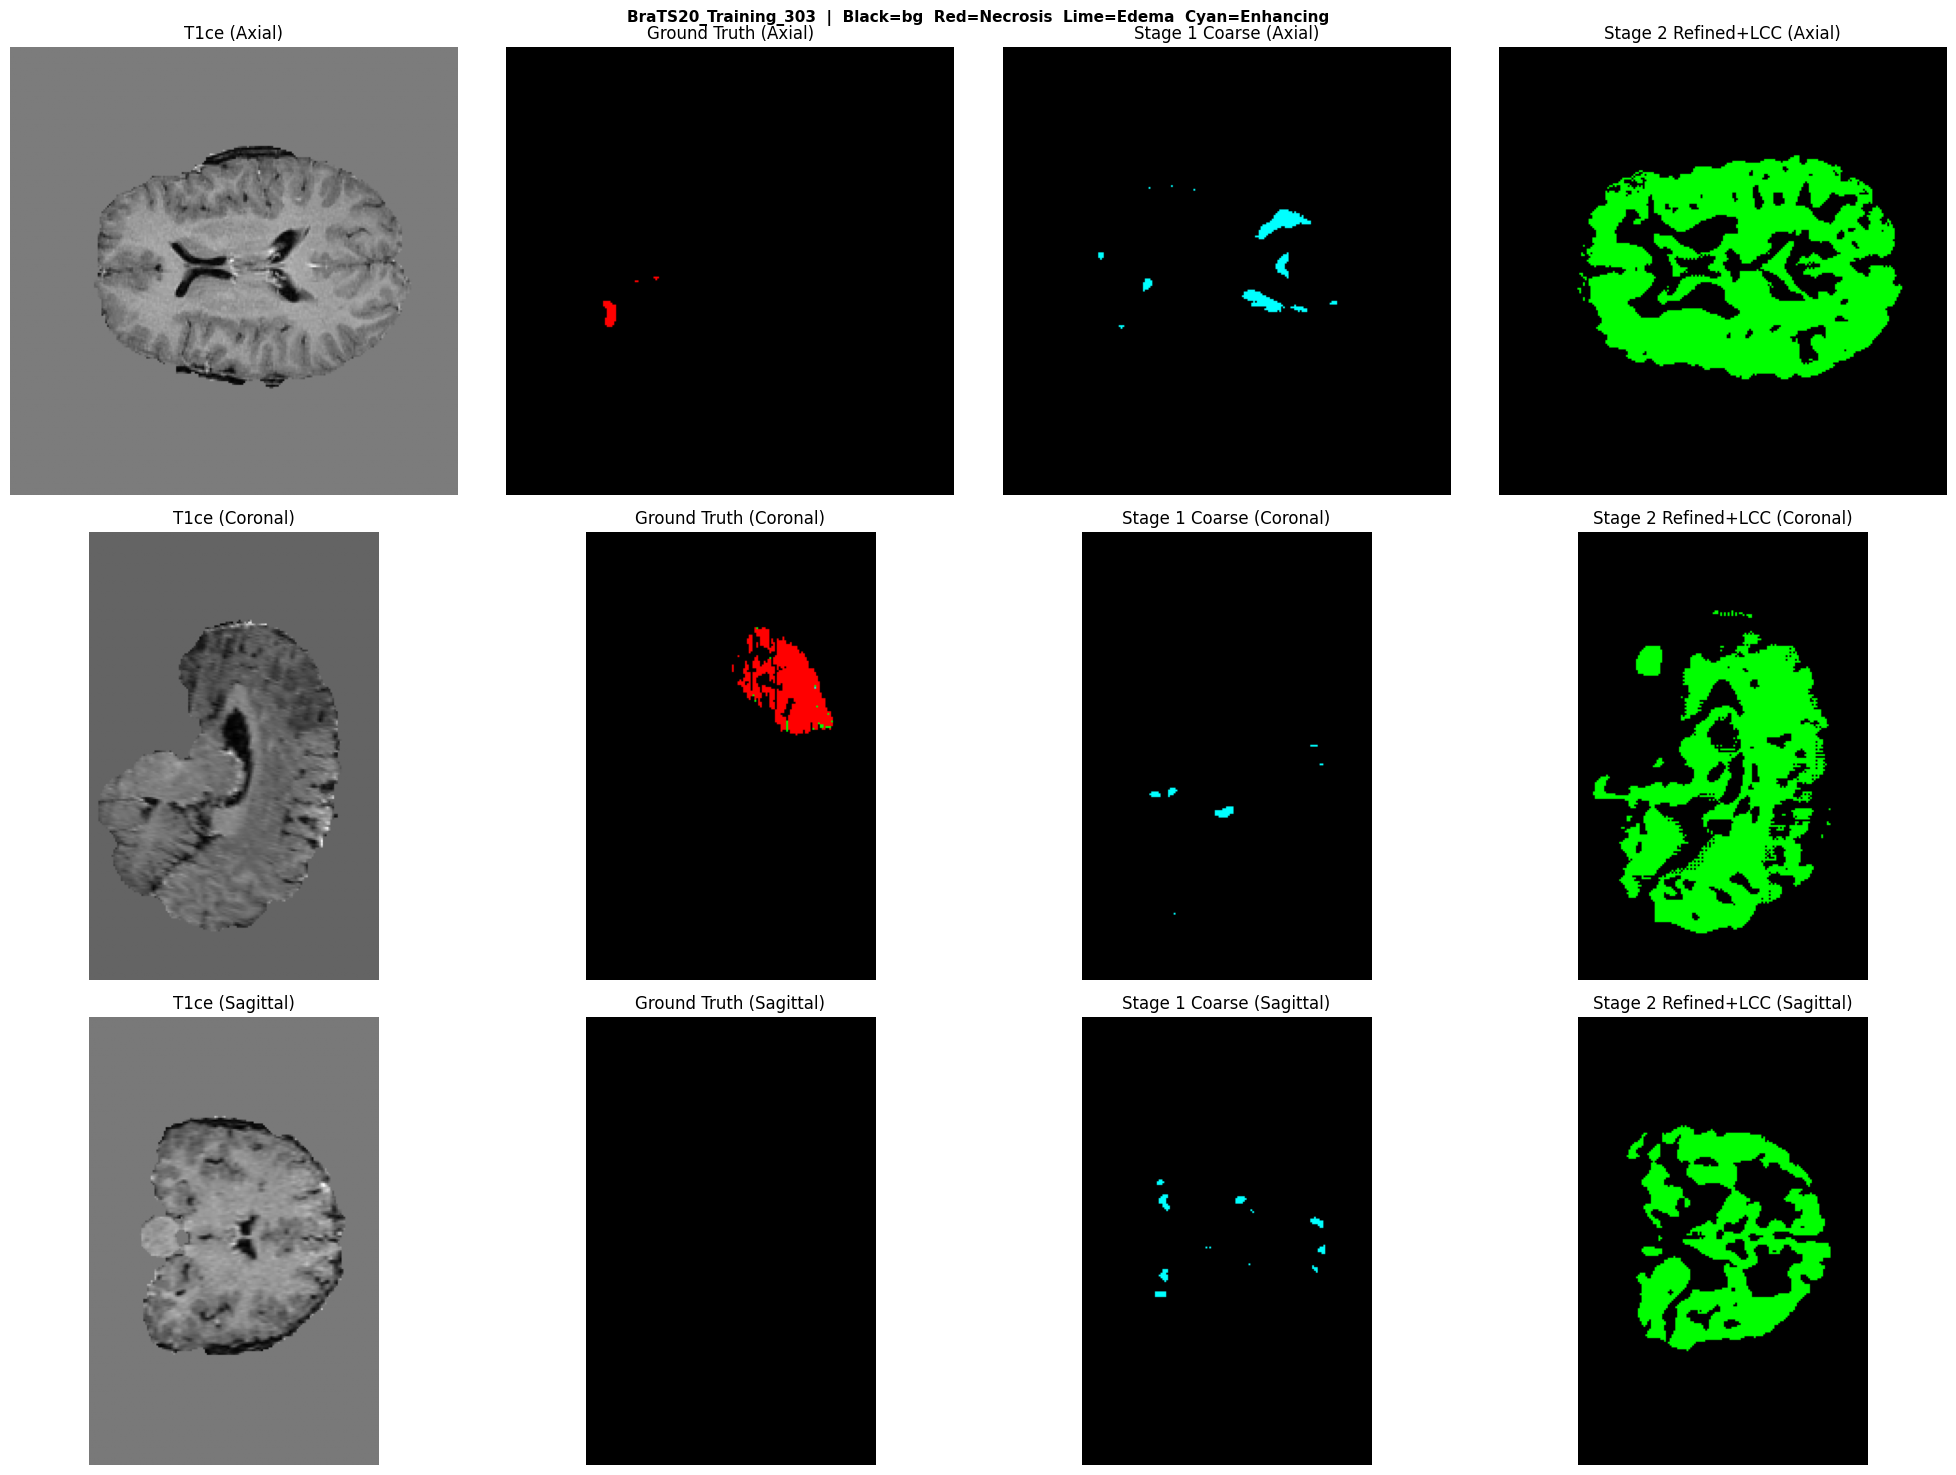


[9/10] BraTS20_Training_304
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_304
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.0090     81.714    48.719   0.0045   0.9386
  Enhancing      0.0000        inf       inf   0.0000      nan


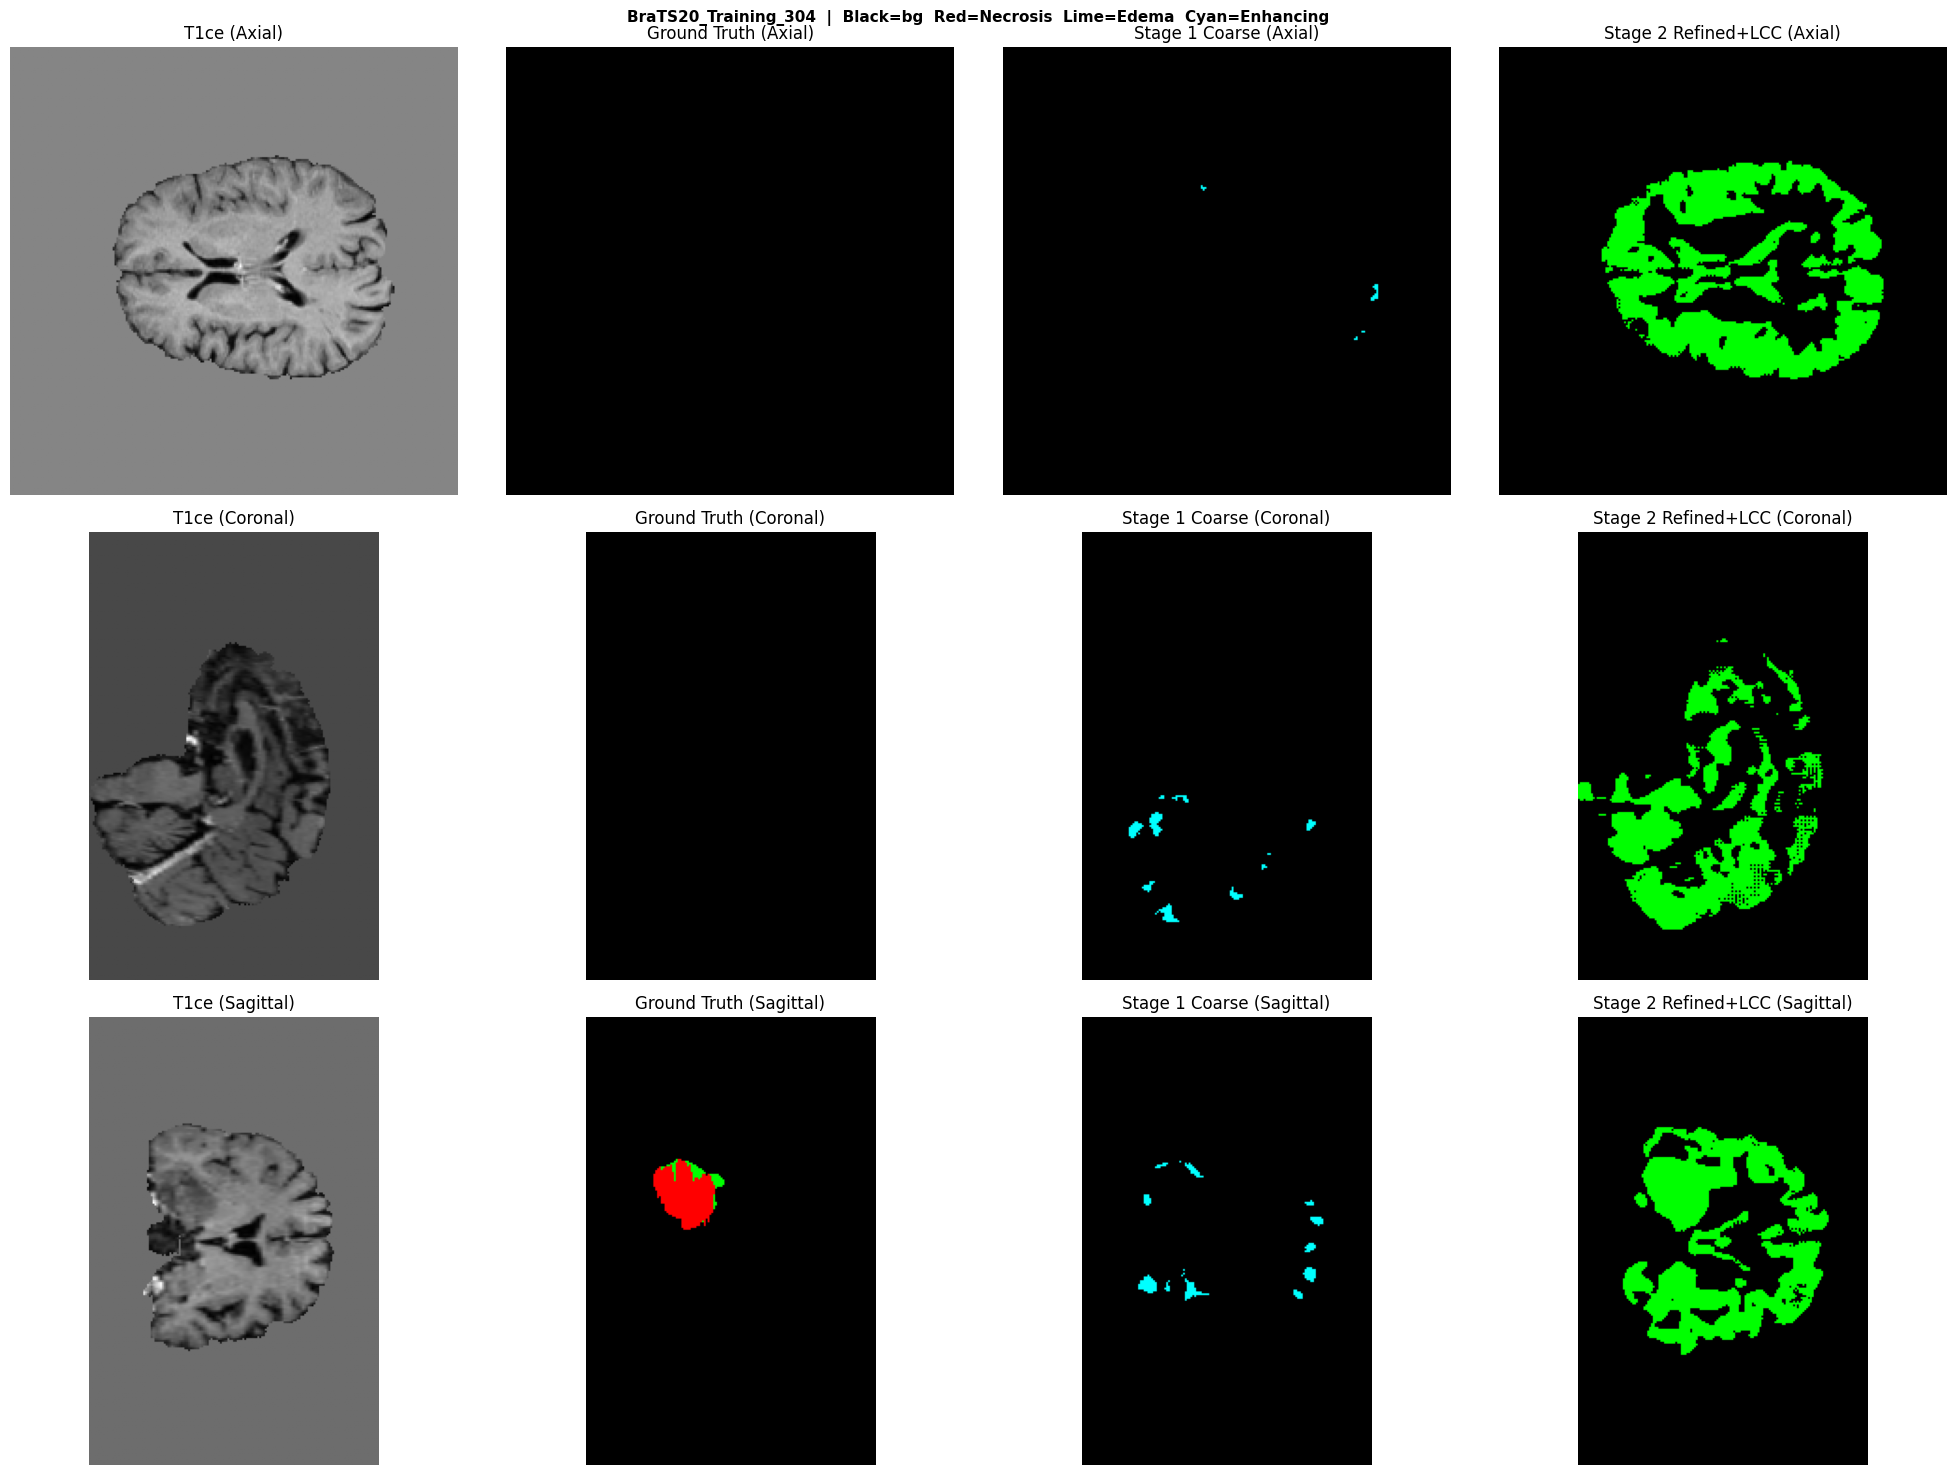


[10/10] BraTS20_Training_305
  Sliding-window: 196 patches (7x7x4)
  Inference complete -> (240, 240, 155, 4)

------------------------------------------------------------
  Patient: BraTS20_Training_305
  Class             DSC   HD95(mm)   ASD(mm)     Prec   Recall
  ----------------------------------------------------------
  Necrosis       0.0000        inf       inf      nan   0.0000
  Edema          0.1027     85.155    35.812   0.0543   0.9523
  Enhancing      0.0000        inf       inf   0.0000      nan


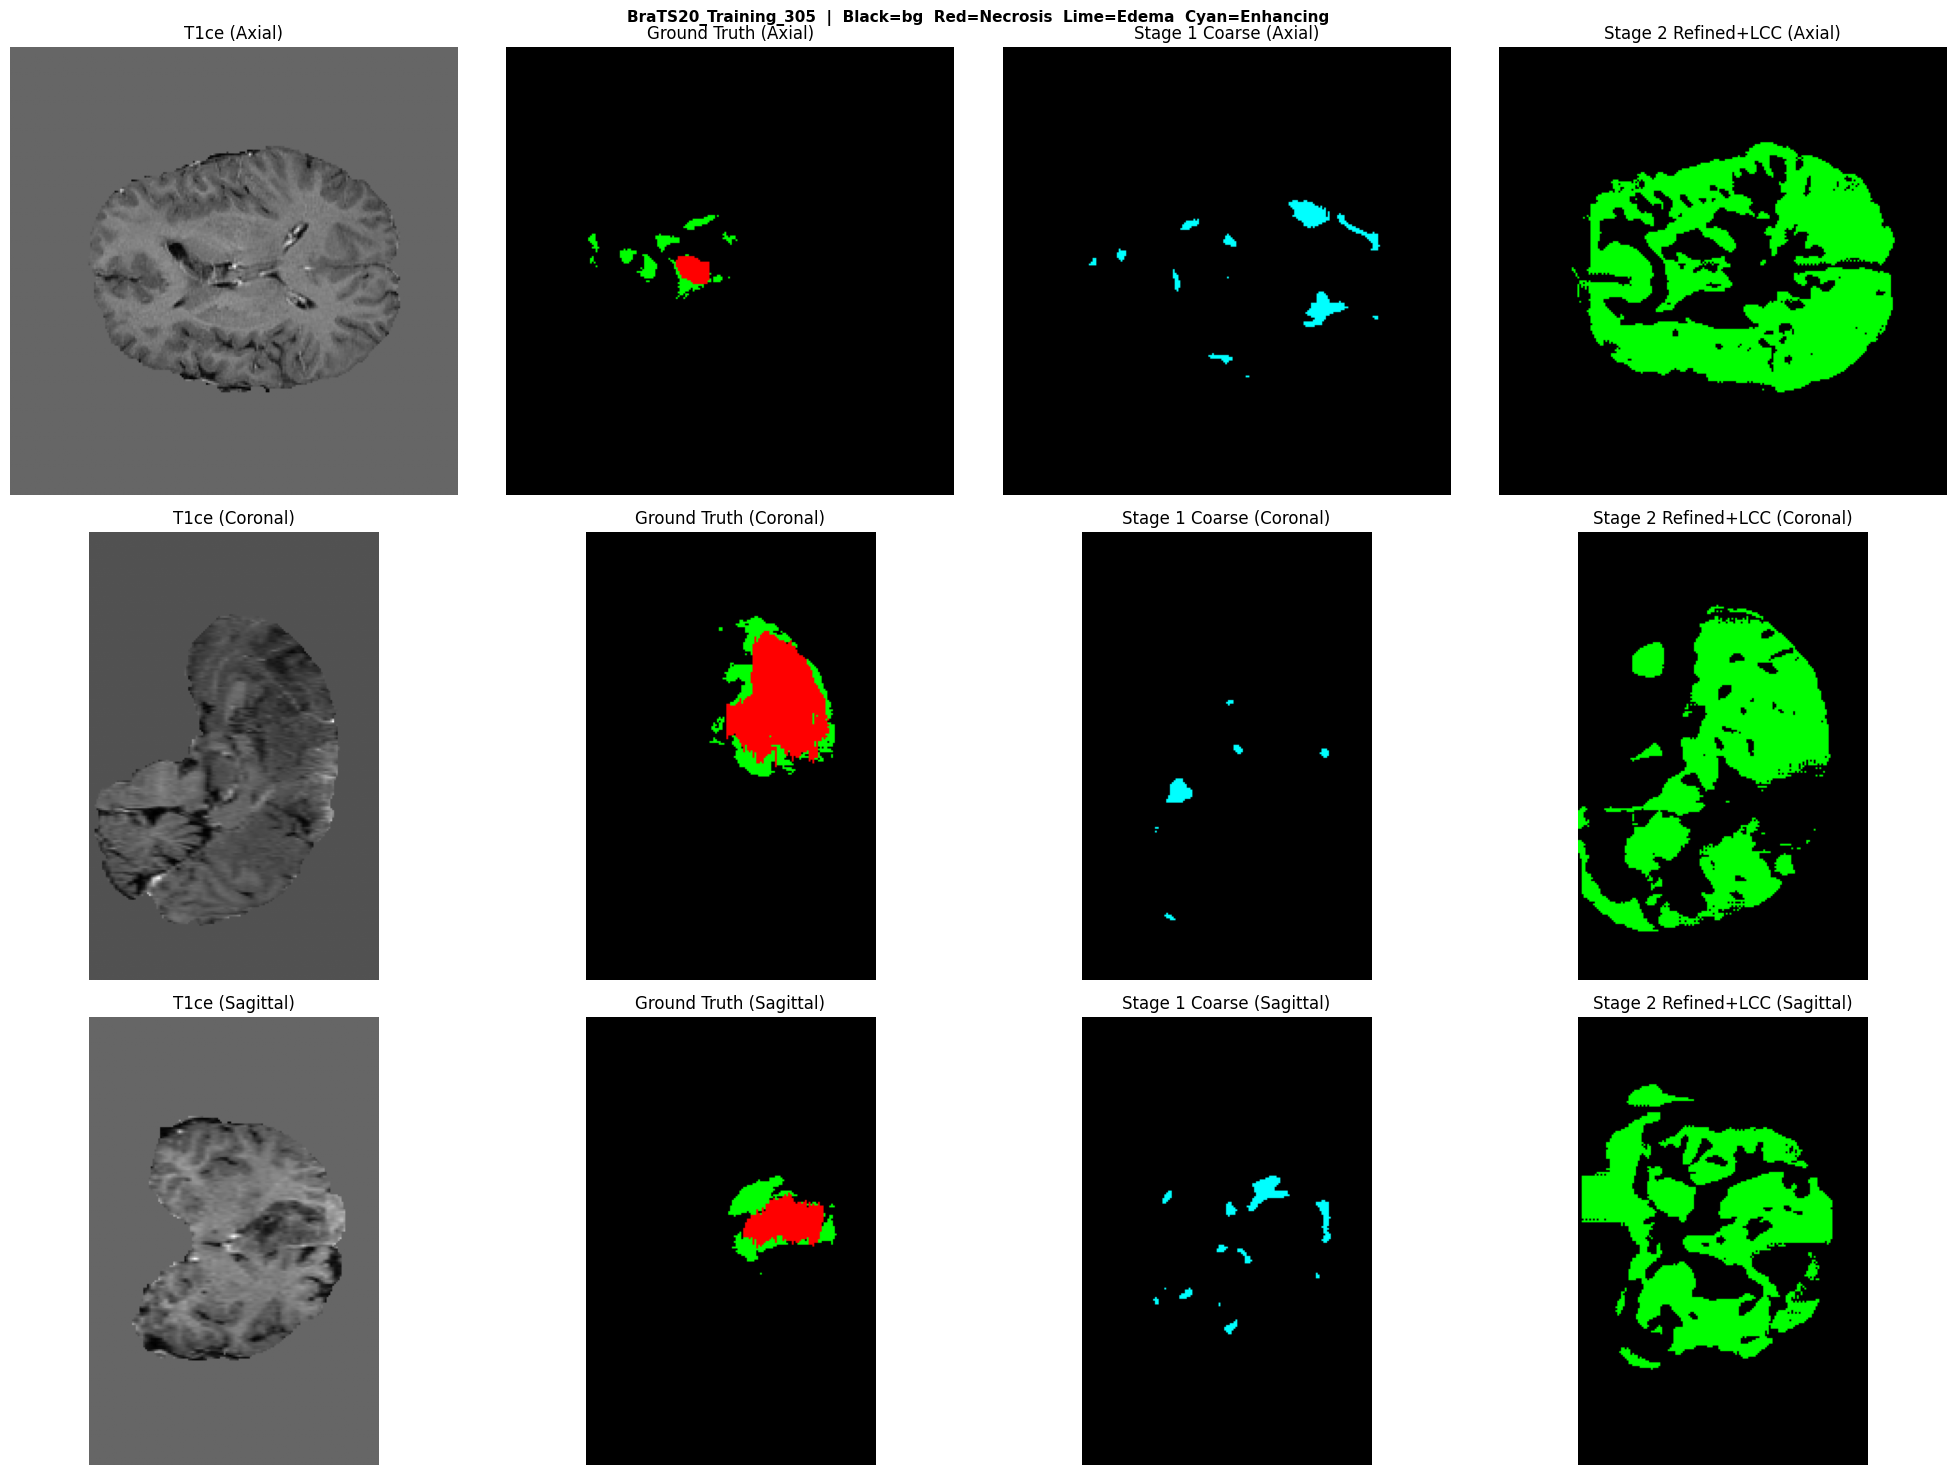


 AGGREGATE METRICS (mean +/- std)
  Class                      DSC         HD95(mm)        ASD(mm)
------------------------------------------------------------
  Necrosis       0.0000+/-0.0000              N/A            N/A
  Edema          0.0787+/-0.0591 87.7998+/-8.1438 42.7060+/-5.6459
  Enhancing      0.0000+/-0.0000 141.1216+/-29.8240 117.6634+/-30.1784
Results saved in: saved_models/buc_net


In [16]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
# ckpt_path is set in Cell 9. Define a fallback in case Cell 9 was skipped.
if 'ckpt_path' not in dir():
    ckpt_path = os.path.join(SAVE_DIR, 'buc_net_best.keras')

if os.path.exists(ckpt_path):
    print(f'Loading best checkpoint: {ckpt_path}')
    buc_net = tf.keras.models.load_model(
        ckpt_path,
        custom_objects={
            'InstanceNormalization': InstanceNormalization,
            'DiceCELoss':            DiceCELoss,
            'DiceFocalLoss':         DiceFocalLoss,
            'MultiClassDiceLoss':    MultiClassDiceLoss,
            'MultiClassFocalLoss':   MultiClassFocalLoss,
        }
    )
    print('Checkpoint loaded.')
else:
    print(f'No checkpoint at {ckpt_path} — using current model weights.')

N_INF    = min(10, len(val_folders))
inf_pats = val_folders[:N_INF]
all_mets = []

# Color map: black=bg, red=necrosis, lime=edema, cyan=enhancing
SEG_CMAP = mcolors.ListedColormap(['black', 'red', 'lime', 'cyan'])
SEG_NORM = mcolors.BoundaryNorm([0, 1, 2, 3, 4], SEG_CMAP.N)

for i, ppath in enumerate(inf_pats, 1):
    pid = os.path.basename(ppath)
    print(f'\n[{i}/{N_INF}] {pid}')

    paths = {m: os.path.join(ppath, f'{pid}_{m}.nii') for m in MODALITIES + ['seg']}

    # Load and normalize
    mods   = [nib.load(paths[m]).get_fdata().astype(np.float32) for m in MODALITIES]
    volume = normalize_volume(np.stack(mods, axis=-1))

    seg_nib = nib.load(paths['seg'])
    gt_raw  = seg_nib.get_fdata().astype(np.int32)
    gt_seg  = remap_labels(gt_raw)
    spacing = tuple(float(v) for v in seg_nib.header.get_zooms()[:3])

    # Gaussian sliding-window inference -> [coarse, refined] probability maps
    coarse_prob, refined_prob = predict_volume_gaussian(buc_net, volume)

    # Post-process: argmax + largest connected component (Stage 2 only)
    coarse_seg  = postprocess_prediction(coarse_prob,  apply_lcc=False)
    refined_seg = postprocess_prediction(refined_prob, apply_lcc=True)

    # Metrics on refined prediction
    mets = compute_all_metrics(gt_seg, refined_seg, sp=spacing)
    print_metrics(pid, mets)
    # ── Volume statistics (voxels per class) ──────────────────────────────
    total_vox = gt_seg.size
    gt_vols, pred_vols = {}, {}
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        gt_v   = int(np.sum(gt_seg    == cls_idx))
        pred_v = int(np.sum(refined_seg == cls_idx))
        gt_vols[cls_name]   = gt_v
        pred_vols[cls_name] = pred_v

    all_mets.append({
        'patient_id': pid,
        'gt_vols':    gt_vols,
        'pred_vols':  pred_vols,
        'total_vox':  total_vox,
        **mets,
    })

    # ── 3-view visualization (Axial / Coronal / Sagittal) ────────────────────
    H, W, D = gt_seg.shape
    views = [
        ('Axial',    volume[:, :, D//2, 2],  gt_seg[:, :, D//2],
                     coarse_seg[:, :, D//2],  refined_seg[:, :, D//2]),
        ('Coronal',  volume[H//2, :, :, 2],  gt_seg[H//2, :, :],
                     coarse_seg[H//2, :, :],  refined_seg[H//2, :, :]),
        ('Sagittal', volume[:, W//2, :, 2],  gt_seg[:, W//2, :],
                     coarse_seg[:, W//2, :],  refined_seg[:, W//2, :]),
    ]

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle(
        f'{pid}  |  Black=bg  Red=Necrosis  Lime=Edema  Cyan=Enhancing',
        fontsize=11, fontweight='bold'
    )
    for row, (vname, t1ce, gt_sl, cs_sl, rs_sl) in enumerate(views):
        axes[row, 0].imshow(t1ce,  cmap='gray')
        axes[row, 0].set_title(f'T1ce ({vname})')
        axes[row, 1].imshow(gt_sl, cmap=SEG_CMAP, norm=SEG_NORM)
        axes[row, 1].set_title(f'Ground Truth ({vname})')
        axes[row, 2].imshow(cs_sl, cmap=SEG_CMAP, norm=SEG_NORM)
        axes[row, 2].set_title(f'Stage 1 Coarse ({vname})')
        axes[row, 3].imshow(rs_sl, cmap=SEG_CMAP, norm=SEG_NORM)
        axes[row, 3].set_title(f'Stage 2 Refined+LCC ({vname})')
        for ax in axes[row]:
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{pid}_pred.png'), dpi=120, bbox_inches='tight')
    plt.show()


# ── Aggregate metrics summary ─────────────────────────────────────────────────
def _fmt(vals):
    """Format mean +/- std; returns 'N/A' for empty or all-NaN lists."""
    return f'{np.mean(vals):.4f}+/-{np.std(vals):.4f}' if vals else 'N/A'


print('\n' + '='*60)
print(' AGGREGATE METRICS (mean +/- std)')
print('='*60)
print(f'  {"Class":<13} {"DSC":>16} {"HD95(mm)":>16} {"ASD(mm)":>14}')
print('-'*60)

for cn in CLASS_NAMES[1:]:
    dv = [m[cn]['DSC']     for m in all_mets if cn in m and np.isfinite(m[cn]['DSC'])]
    hv = [m[cn]['HD95_mm'] for m in all_mets if cn in m and np.isfinite(m[cn]['HD95_mm'])]
    av = [m[cn]['ASD_mm']  for m in all_mets if cn in m and np.isfinite(m[cn]['ASD_mm'])]
    print(f'  {cn:<13} {_fmt(dv):>16} {_fmt(hv):>16} {_fmt(av):>14}')

print('='*60)
print(f'Results saved in: {SAVE_DIR}')



════════════════════════════════════════════════════════════════════════════════════════════════════
  PER-PATIENT GROUND-TRUTH vs PREDICTION COMPARISON
════════════════════════════════════════════════════════════════════════════════════════════════════
  Patient                         Metric            Necrosis          Edema      Enhancing
────────────────────────────────────────────────────────────────────────────────────────────────────
  BraTS20_Training_296            GT vox              72,158         72,771         17,176
  BraTS20_Training_296            Pred vox                 0        974,136          8,500
  BraTS20_Training_296            GT %                 0.81%          0.82%          0.19%
  BraTS20_Training_296            Pred %               0.00%         10.91%          0.10%
                                  DSC                 0.0000         0.1352         0.0000
                                  HD95_mm                N/A        75.9671       141.4438
       

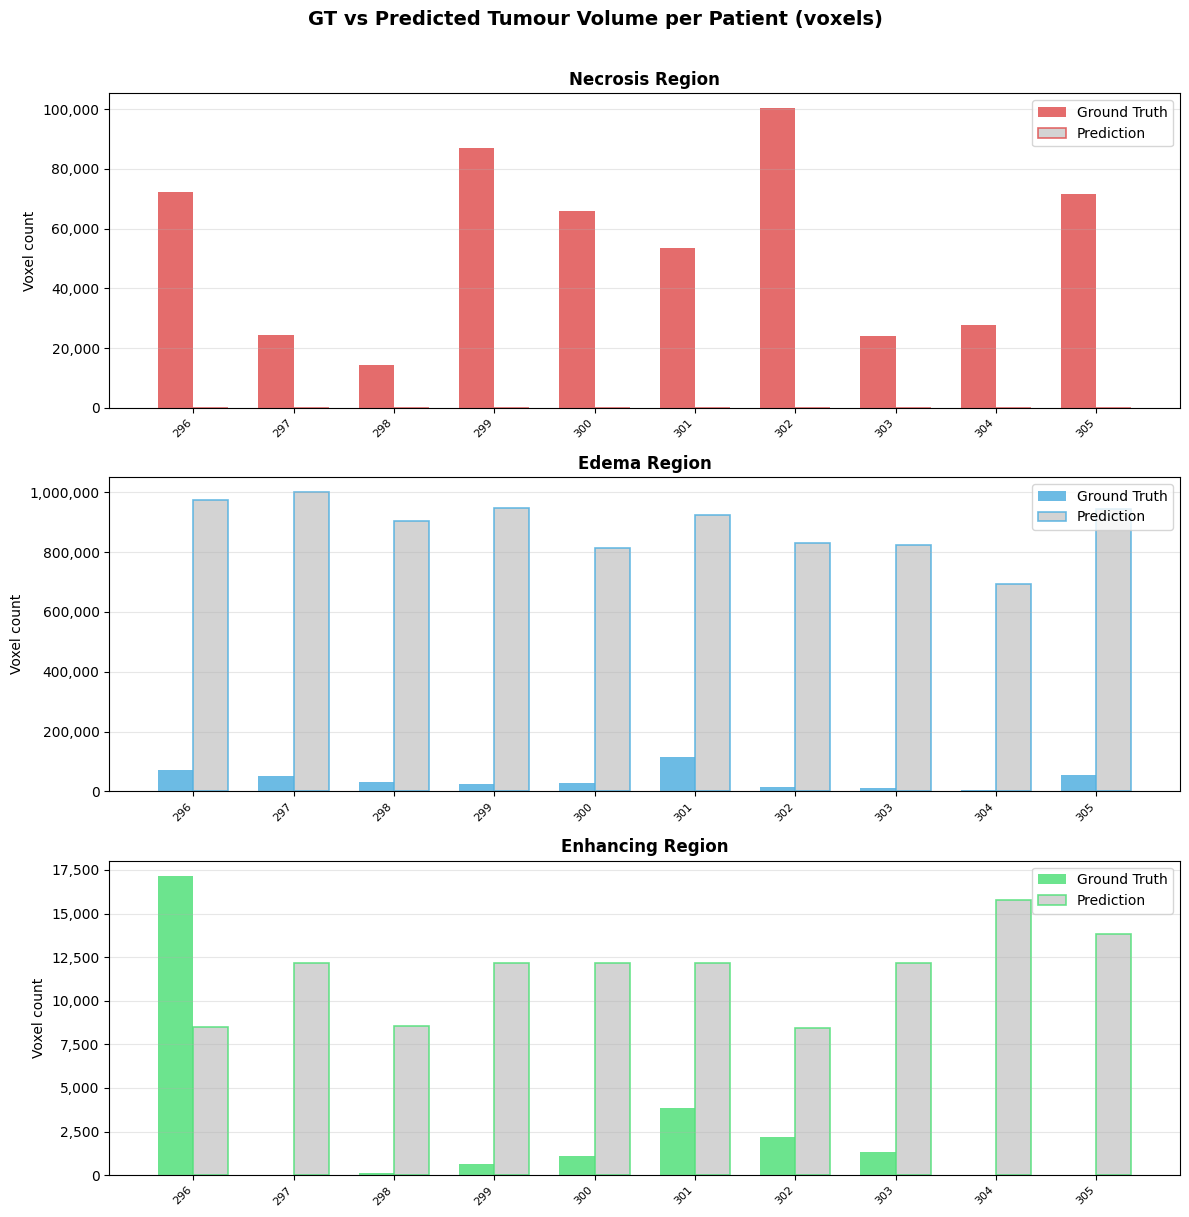

Saved → saved_models/buc_net/comparison_volume_bars.png


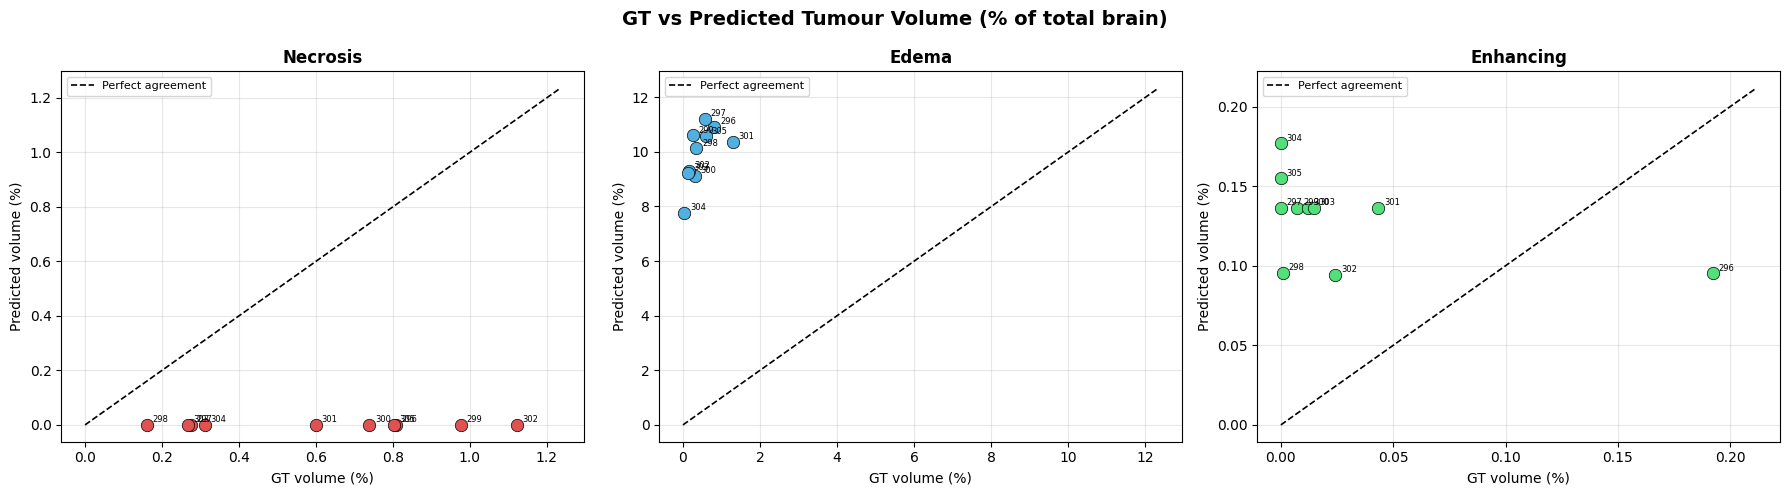

Saved → saved_models/buc_net/comparison_volume_pct.png


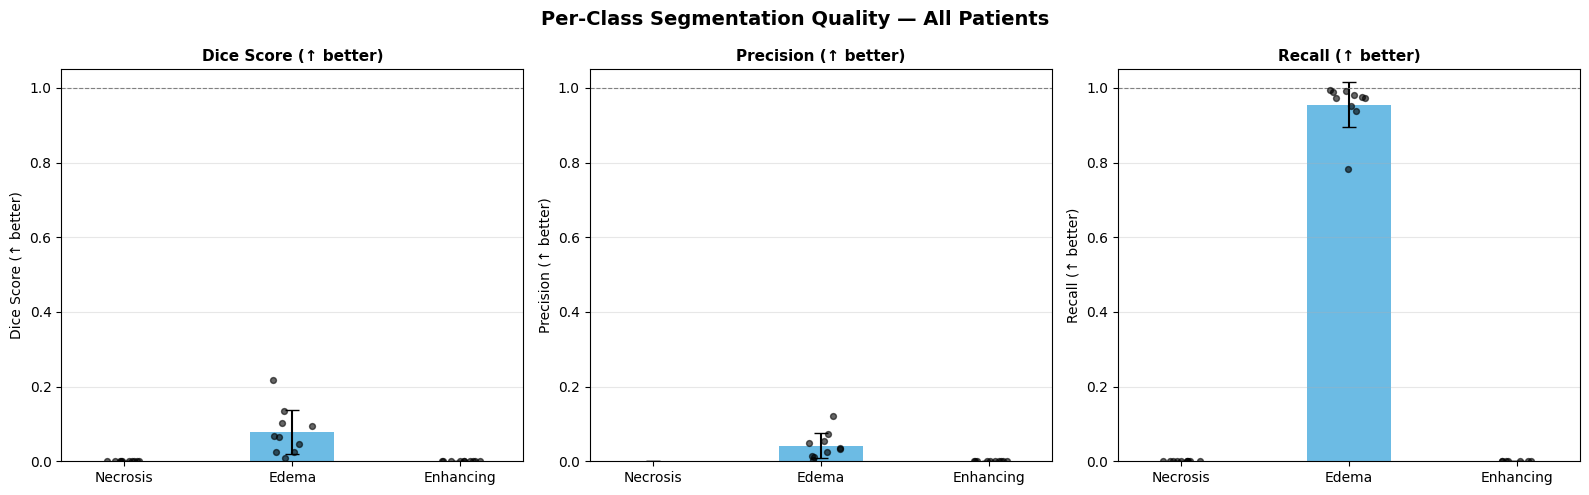

Saved → saved_models/buc_net/comparison_metrics_bars.png


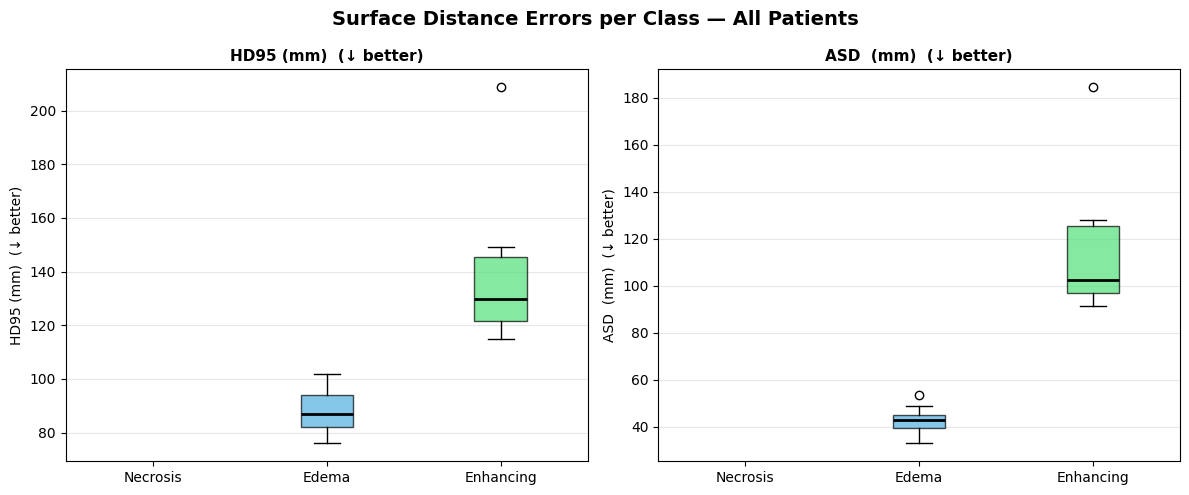

Saved → saved_models/buc_net/comparison_distances.png

✓ All comparison figures saved to: saved_models/buc_net


In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 15 — Ground-Truth vs Prediction: Full Statistical Comparison
# ═══════════════════════════════════════════════════════════════════════════════
# Requires: all_mets populated by the inference cell above.
# Produces:
#   • Printed per-patient table  (GT voxels vs Pred voxels, all metrics)
#   • Printed aggregate table    (mean ± std across patients)
#   • 4 saved figures in SAVE_DIR:
#       comparison_volume_bars.png   – GT vs Pred tumour volumes per patient
#       comparison_volume_pct.png    – Same as % of total brain volume
#       comparison_metrics_bars.png  – DSC / Precision / Recall per class
#       comparison_distances.png     – HD95 / ASD per class
# ═══════════════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

_FORE_CLASSES = CLASS_NAMES[1:]   # exclude Background for tumour stats
_VOXEL_MM3    = 1.0               # placeholder; spacing varies per patient

# ── helpers ──────────────────────────────────────────────────────────────────
def _vals(key, sub, patients=all_mets):
    """Collect finite floats for metric `key` / class `sub` across all patients."""
    out = []
    for m in patients:
        if sub in m and isinstance(m[sub], dict) and key in m[sub]:
            v = m[sub][key]
            if np.isfinite(v):
                out.append(v)
    return out

def _mu_sd(lst):
    if not lst:
        return float('nan'), float('nan')
    return float(np.mean(lst)), float(np.std(lst))

def _fmtv(v, unit=''):
    return f'{v:,.0f}{unit}' if np.isfinite(v) else 'N/A'

# ── 1. Per-patient printed table ─────────────────────────────────────────────
print('\n' + '═'*100)
print('  PER-PATIENT GROUND-TRUTH vs PREDICTION COMPARISON')
print('═'*100)

hdr_cls = ''.join(f'{c:>15}' for c in _FORE_CLASSES)
print(f"  {'Patient':<30}  {'Metric':<11}" + hdr_cls)
print('─'*100)

for m in all_mets:
    pid = m['patient_id']
    tv  = m.get('total_vox', 1)

    # Volume rows
    for label, vol_key in [('GT vox',   'gt_vols'),
                             ('Pred vox', 'pred_vols'),
                             ('GT %',     'gt_vols'),
                             ('Pred %',   'pred_vols')]:
        row = f"  {pid:<30}  {label:<11}"
        for cn in _FORE_CLASSES:
            
            v = m.get(vol_key, {}).get(cn, 0)
            if '%' in label:
                row += f'{v/tv*100:>14.2f}%'
            else:
                row += f'{v:>15,}'
        print(row)

    # Metric rows
    for metric in ['DSC', 'HD95_mm', 'ASD_mm', 'Precision', 'Recall']:
        row = f"  {'':30}  {metric:<11}"
        for cn in _FORE_CLASSES:
            if cn in m and isinstance(m[cn], dict):
                v = m[cn].get(metric, float('nan'))
                row += f'{v:>15.4f}' if np.isfinite(v) else f"{'N/A':>15}"
            else:
                row += f"{'N/A':>15}"
        print(row)
    print('─'*100)

# ── 2. Aggregate table ────────────────────────────────────────────────────────
print('\n' + '═'*90)
print('  AGGREGATE STATISTICS  (mean ± std across all evaluated patients)')
print('═'*90)

agg_hdr = ''.join(f'{c:>25}' for c in _FORE_CLASSES)
print(f"  {'Metric':<18}" + agg_hdr)
print('─'*90)

# Volume aggregates (in voxels)
for vol_key, label in [('gt_vols', 'GT vol (vox)'), ('pred_vols', 'Pred vol (vox)')]:
    row = f'  {label:<18}'
    for cn in _FORE_CLASSES:
        vals = [m.get(vol_key, {}).get(cn, 0) for m in all_mets]
        mu, sd = _mu_sd(vals)
        row += f'{mu:>12,.0f}±{sd:>10,.0f}'
    print(row)

# Volume % aggregates
for vol_key, label in [('gt_vols', 'GT vol (%)'), ('pred_vols', 'Pred vol (%)')]:
    row = f'  {label:<18}'
    for cn in _FORE_CLASSES:
        vals = [m.get(vol_key, {}).get(cn, 0) / max(m.get('total_vox', 1), 1) * 100
                for m in all_mets]
        mu, sd = _mu_sd(vals)
        row += f'{mu:>11.3f}% ±{sd:>7.3f}%'
    print(row)

print('─'*90)
for metric, label in [('DSC', 'DSC'), ('HD95_mm', 'HD95 (mm)'),
                       ('ASD_mm', 'ASD (mm)'), ('Precision', 'Precision'),
                       ('Recall', 'Recall')]:
    row = f'  {label:<18}'
    for cn in _FORE_CLASSES:
        vals = _vals(metric, cn)
        mu, sd = _mu_sd(vals)
        row += f'{mu:>12.4f}±{sd:>10.4f}' if np.isfinite(mu) else f"{'N/A':>23}"
    print(row)
print('═'*90)

# ── 3. Figure A: GT vs Pred tumour volume (voxel count, per patient) ─────────
n_pat  = len(all_mets)
n_cls  = len(_FORE_CLASSES)
x      = np.arange(n_pat)
width  = 0.35 / n_cls          # thin bars side-by-side
colors = ['#e05252', '#52b0e0', '#52e07a']   # red, blue, green

fig, axes = plt.subplots(n_cls, 1, figsize=(max(10, n_pat * 1.2), 4 * n_cls),
                          sharex=False)
if n_cls == 1:
    axes = [axes]

fig.suptitle('GT vs Predicted Tumour Volume per Patient (voxels)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, cn, col in zip(axes, _FORE_CLASSES, colors):
    gt_v   = [m.get('gt_vols',   {}).get(cn, 0) for m in all_mets]
    pred_v = [m.get('pred_vols', {}).get(cn, 0) for m in all_mets]
    pids   = [m['patient_id'].replace('BraTS20_Training_', '') for m in all_mets]

    bw = 0.35
    b1 = ax.bar(x - bw/2, gt_v,   bw, label='Ground Truth', color=col,      alpha=0.85)
    b2 = ax.bar(x + bw/2, pred_v, bw, label='Prediction',   color='#cccccc', alpha=0.85,
                edgecolor=col, linewidth=1.2)
    ax.set_title(f'{cn} Region', fontsize=12, fontweight='bold')
    ax.set_ylabel('Voxel count')
    ax.set_xticks(x)
    ax.set_xticklabels(pids, rotation=45, ha='right', fontsize=8)
    ax.legend(loc='upper right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_a = os.path.join(SAVE_DIR, 'comparison_volume_bars.png')
plt.savefig(out_a, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {out_a}')

# ── 4. Figure B: GT vs Pred volume as % of total brain volume ────────────────
fig, axes = plt.subplots(1, n_cls, figsize=(6 * n_cls, 5), sharey=False)
if n_cls == 1:
    axes = [axes]

fig.suptitle('GT vs Predicted Tumour Volume (% of total brain)',
             fontsize=14, fontweight='bold')

for ax, cn, col in zip(axes, _FORE_CLASSES, colors):
    pids   = [m['patient_id'].replace('BraTS20_Training_', '') for m in all_mets]
    gt_pct = [m.get('gt_vols',   {}).get(cn, 0) / max(m.get('total_vox', 1), 1) * 100
              for m in all_mets]
    pd_pct = [m.get('pred_vols', {}).get(cn, 0) / max(m.get('total_vox', 1), 1) * 100
              for m in all_mets]

    ax.scatter(gt_pct, pd_pct, c=col, s=80, zorder=3, edgecolors='k', linewidths=0.5)
    lim = max(max(gt_pct + pd_pct, default=1) * 1.1, 0.1)
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Perfect agreement')
    for g, p, pid in zip(gt_pct, pd_pct, pids):
        ax.annotate(pid, (g, p), textcoords='offset points', xytext=(4, 2), fontsize=6)
    ax.set_xlabel('GT volume (%)')
    ax.set_ylabel('Predicted volume (%)')
    ax.set_title(f'{cn}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_b = os.path.join(SAVE_DIR, 'comparison_volume_pct.png')
plt.savefig(out_b, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {out_b}')

# ── 5. Figure C: DSC / Precision / Recall per class ─────────────────────────
metrics_ABC = [('DSC', 'Dice Score (↑ better)', '#4c9be8'),
               ('Precision', 'Precision (↑ better)', '#e87d4c'),
               ('Recall',    'Recall (↑ better)',    '#5cc45c')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Per-Class Segmentation Quality — All Patients',
             fontsize=14, fontweight='bold')

for ax, (mkey, mlabel, mcol) in zip(axes, metrics_ABC):
    class_data = []
    for cn in _FORE_CLASSES:
        class_data.append(_vals(mkey, cn))

    bw    = 0.5
    xpos  = np.arange(n_cls)
    means = [np.mean(v) if v else 0 for v in class_data]
    stds  = [np.std(v)  if v else 0 for v in class_data]

    bars = ax.bar(xpos, means, bw, yerr=stds, capsize=5,
                  color=[colors[k % len(colors)] for k in range(n_cls)],
                  alpha=0.85, error_kw={'elinewidth': 1.5})

    # overlay individual patient points
    for k, (cn, vals) in enumerate(zip(_FORE_CLASSES, class_data)):
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(k + jitter, vals, color='k', s=18, zorder=4, alpha=0.6)

    ax.set_xticks(xpos)
    ax.set_xticklabels(_FORE_CLASSES, fontsize=10)
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_c = os.path.join(SAVE_DIR, 'comparison_metrics_bars.png')
plt.savefig(out_c, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {out_c}')

# ── 6. Figure D: HD95 / ASD per class ────────────────────────────────────────
metrics_D = [('HD95_mm', 'HD95 (mm)  (↓ better)', '#9b59b6'),
             ('ASD_mm',  'ASD  (mm)  (↓ better)',  '#e74c3c')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Surface Distance Errors per Class — All Patients',
             fontsize=14, fontweight='bold')

for ax, (mkey, mlabel, mcol) in zip(axes, metrics_D):
    class_data = []
    for cn in _FORE_CLASSES:
        class_data.append(_vals(mkey, cn))

    bp = ax.boxplot(class_data if any(class_data) else [[0]] * n_cls,
                    patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'lw': 2})
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)

    ax.set_xticklabels(_FORE_CLASSES, fontsize=10)
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_d = os.path.join(SAVE_DIR, 'comparison_distances.png')
plt.savefig(out_d, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {out_d}')

print('\n✓ All comparison figures saved to:', SAVE_DIR)
